In [1]:
# ============================================================================
# GERAÇÃO DE DADOS SINTÉTICOS USANDO LATIN HYPERCUBE SAMPLING (LHS)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.stats import qmc
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("GERAÇÃO DE DADOS SINTÉTICOS - HIDRÓLISE ENZIMÁTICA")
print("Latin Hypercube Sampling + Modelo Mecanístico")
print("=" * 80)

GERAÇÃO DE DADOS SINTÉTICOS - HIDRÓLISE ENZIMÁTICA
Latin Hypercube Sampling + Modelo Mecanístico


In [2]:
# ============================================================================
# 1. DEFINIÇÃO DOS PARÂMETROS DE VARIAÇÃO
# ============================================================================

print("\n1. DEFININDO RANGOS DE PARÂMETROS...")

# Definir os rangos de variação para cada parâmetro
param_ranges = {
    'solids_loading': (50.0, 250.0),         # g/L - carregamento de sólidos
    'enzyme_loading': (0.05, 1.2),           # g/L - carregamento de enzimas
    'cellulose_fraction': (0.45, 0.65),      # fração de celulose na biomassa
    'hemicellulose_fraction': (0.05, 0.15),  # fração de hemicelulose na biomassa
}

# Tempos específicos para simulação (baseados nos dados experimentais)
time_points = np.array([0, 1, 2, 4, 6, 8, 12, 24, 48, 72, 96])  # horas

print(f"✓ Solids Loading: {param_ranges['solids_loading'][0]:.1f} - {param_ranges['solids_loading'][1]:.1f} g/L")
print(f"✓ Enzyme Loading: {param_ranges['enzyme_loading'][0]:.2f} - {param_ranges['enzyme_loading'][1]:.2f} g/L")
print(f"✓ Celulose: {param_ranges['cellulose_fraction'][0]*100:.0f}% - {param_ranges['cellulose_fraction'][1]*100:.0f}%")
print(f"✓ Hemicelulose: {param_ranges['hemicellulose_fraction'][0]*100:.0f}% - {param_ranges['hemicellulose_fraction'][1]*100:.0f}%")
print(f"✓ Lignina: calculada automaticamente (20-30%)")
print(f"✓ Tempos de simulação: {len(time_points)} pontos - {time_points}")

# Número de combinações únicas de condições para gerar
n_conditions = 100  # Isso gerará 100 × 11 tempos = 1100 amostras no total

print(f"\n📊 ESTRATÉGIA DE AMOSTRAGEM:")
print(f"   • {n_conditions} combinações únicas de condições (LHS)")
print(f"   • {len(time_points)} tempos por condição")
print(f"   • Total de amostras: {n_conditions * len(time_points)}")
print(f"   • Lignina restrita a 20-30% através de amostragem condicionada")


1. DEFININDO RANGOS DE PARÂMETROS...
✓ Solids Loading: 50.0 - 250.0 g/L
✓ Enzyme Loading: 0.05 - 1.20 g/L
✓ Celulose: 45% - 65%
✓ Hemicelulose: 5% - 15%
✓ Lignina: calculada automaticamente (20-30%)
✓ Tempos de simulação: 11 pontos - [ 0  1  2  4  6  8 12 24 48 72 96]

📊 ESTRATÉGIA DE AMOSTRAGEM:
   • 100 combinações únicas de condições (LHS)
   • 11 tempos por condição
   • Total de amostras: 1100
   • Lignina restrita a 20-30% através de amostragem condicionada


In [3]:
# ============================================================================
# 2. FUNÇÃO PARA GERAR AMOSTRAS LHS COM RESTRIÇÕES
# ============================================================================

def generate_lhs_samples_with_constraints(n_samples, param_ranges, lignin_range=(0.20, 0.30)):
    """
    Gera amostras usando Latin Hypercube Sampling com restrições de lignina
    
    Parameters:
    -----------
    n_samples : int
        Número de amostras a gerar
    param_ranges : dict
        Dicionário com os rangos de cada parâmetro
    lignin_range : tuple
        Range permitido para fração de lignina (min, max)
    
    Returns:
    --------
    samples_df : pandas.DataFrame
        DataFrame com as amostras geradas
    """
    
    print(f"\n2. GERANDO {n_samples} AMOSTRAS LHS COM RESTRIÇÕES...")
    
    # Inicializar o sampler LHS
    sampler = qmc.LatinHypercube(d=4, seed=42)  # 4 dimensões
    
    valid_samples = []
    attempts = 0
    max_attempts = n_samples * 10  # Máximo de tentativas
    
    while len(valid_samples) < n_samples and attempts < max_attempts:
        # Gerar batch de amostras
        batch_size = min(100, n_samples - len(valid_samples))
        sample_batch = sampler.random(n=batch_size)
        
        for sample in sample_batch:
            attempts += 1
            
            # Mapear amostras [0,1] para os rangos reais
            solids_loading = param_ranges['solids_loading'][0] + sample[0] * \
                           (param_ranges['solids_loading'][1] - param_ranges['solids_loading'][0])
            
            enzyme_loading = param_ranges['enzyme_loading'][0] + sample[1] * \
                           (param_ranges['enzyme_loading'][1] - param_ranges['enzyme_loading'][0])
            
            cellulose_fraction = param_ranges['cellulose_fraction'][0] + sample[2] * \
                               (param_ranges['cellulose_fraction'][1] - param_ranges['cellulose_fraction'][0])
            
            hemicellulose_fraction = param_ranges['hemicellulose_fraction'][0] + sample[3] * \
                                   (param_ranges['hemicellulose_fraction'][1] - param_ranges['hemicellulose_fraction'][0])
            
            # Calcular lignina
            lignin_fraction = 1.0 - cellulose_fraction - hemicellulose_fraction
            
            # Verificar se a lignina está dentro do range permitido
            if lignin_range[0] <= lignin_fraction <= lignin_range[1]:
                valid_samples.append({
                    'solids_loading': solids_loading,
                    'enzyme_loading': enzyme_loading,
                    'cellulose_fraction': cellulose_fraction,
                    'hemicellulose_fraction': hemicellulose_fraction,
                    'lignin_fraction': lignin_fraction
                })
                
            if len(valid_samples) >= n_samples:
                break
    
    if len(valid_samples) < n_samples:
        print(f"⚠️  Aviso: Apenas {len(valid_samples)} amostras válidas encontradas em {attempts} tentativas")
    
    # Converter para DataFrame
    samples_df = pd.DataFrame(valid_samples)
    
    print(f"✓ {len(samples_df)} amostras geradas com sucesso")
    print(f"✓ Lignina varia de {samples_df['lignin_fraction'].min():.3f} a {samples_df['lignin_fraction'].max():.3f}")
    
    return samples_df

# Gerar as amostras
conditions_df = generate_lhs_samples_with_constraints(n_conditions, param_ranges)


2. GERANDO 100 AMOSTRAS LHS COM RESTRIÇÕES...
✓ 100 amostras geradas com sucesso
✓ Lignina varia de 0.208 a 0.299


In [4]:
# ============================================================================
# 3. MODELO MECANÍSTICO DE HIDRÓLISE ENZIMÁTICA
# ============================================================================

print("\n3. CONFIGURANDO MODELO MECANÍSTICO...")

# Parâmetros cinéticos (Angarita et al. 2015) - FIXOS
k_1r = 0.177              # Taxa de reação r1 (h⁻¹)
k_2r = 8.81               # Taxa de reação r2 (h⁻¹)
k_3r = 201.0              # Taxa de reação r3 (h⁻¹)
k_4r = 16.34              # Taxa de reação r4 (h⁻¹)

# Constantes de inibição - Reação 1
k_11G2 = 0.402            # Inibição por celobiose (g/L)
k_11G = 2.71              # Inibição por glicose (g/L)
k_11X = 2.15              # Inibição por xilose (g/L)

# Constantes de inibição - Reação 2
k_21G2 = 119.6            # Inibição por celobiose (g/L)
k_21G = 4.69              # Inibição por glicose (g/L)
k_21X = 0.095             # Inibição por xilose (g/L)

# Constantes de Michaelis-Menten - Reação 3
k_3M = 26.6               # Constante de Michaelis (g/L)
k_31G = 11.06             # Inibição por glicose (g/L)
k_31X = 1.023             # Inibição por xilose (g/L)

# Constantes de inibição - Reação 4
k_41G2 = 16.25            # Inibição por celobiose (g/L)
k_41G = 4.0               # Inibição por glicose (g/L)
k_41X = 154.0             # Inibição por xilose (g/L)

# Parâmetros de adsorção enzimática
k_ad = 7.16               # Constante de adsorção
E_max = 8.32/1000         # Capacidade máxima de adsorção (g/L)
alfa = 1.0                # Fator de resistência

def calcular_enzima_equilibrio(E_T, S, E_max, k_ad):
    """Calcula enzima livre e adsorvida em equilíbrio"""
    def equation(E_F):
        E_B = E_T - E_F
        return E_max * k_ad * E_F / (1 + k_ad * E_F) - E_B / S
    
    try:
        E_F = fsolve(equation, 0.1)[0]
        E_B = E_T - E_F
        return max(E_F, 0), max(E_B, 0)
    except:
        # Fallback em caso de erro
        return E_T * 0.9, E_T * 0.1

def modelo_hidrolise(t, y, S0):
    """
    Sistema de ODEs para hidrólise enzimática
    
    Variáveis de estado:
    y[0] = C    - Celulose (g/L)
    y[1] = G2   - Celobiose (g/L)
    y[2] = G    - Glicose (g/L)
    y[3] = H    - Hemicelulose (g/L)
    y[4] = X    - Xilose (g/L)
    y[5] = S    - Biomassa total (g/L)
    y[6] = E_B  - Enzima adsorvida (g/L)
    y[7] = E_F  - Enzima livre (g/L)
    """
    
    C, G2, G, H, X, S, E_B, E_F = y
    
    # Evitar divisão por zero e valores negativos
    S = max(S, 1e-6)
    C = max(C, 0)
    H = max(H, 0)
    G2 = max(G2, 0)
    G = max(G, 0)
    X = max(X, 0)
    
    # Fator de resistência
    R_S = alfa * S / S0
    
    # Concentrações de enzima específica
    Ebc = E_B * C / S if S > 0 else 0     # Enzima específica para celulose
    Ebh = E_B * H / S if S > 0 else 0     # Enzima específica para hemicelulose
    
    # Taxas de reação (com proteção contra divisão por zero)
    try:
        r1 = k_1r * Ebc * R_S * C / (1 + G2/k_11G2 + G/k_11G + X/k_11X)
        r2 = k_2r * Ebc * R_S * C / (1 + G2/k_21G2 + G/k_21G + X/k_21X)
        r3 = k_3r * E_F * G2 / (k_3M * (1 + G/k_31G + X/k_31X) + G2)
        r4 = k_4r * Ebh * R_S * H / (1 + G2/k_41G2 + G/k_41G + X/k_41X)
    except:
        r1 = r2 = r3 = r4 = 0
    
    # Equações diferenciais
    dCdt = -r1 - r2                 # Celulose
    dG2dt = 1.056 * r1 - r3         # Celobiose
    dGdt = 1.111 * r2 + 1.053 * r3  # Glicose
    dHdt = -r4                      # Hemicelulose
    dXdt = 1.136 * r4               # Xilose
    dSdt = -r1 - r2 - r4            # Biomassa
    
    # Enzimas (equações algébricas - derivadas = 0)
    dE_Bdt = 0
    dE_Fdt = 0
    
    return [dCdt, dG2dt, dGdt, dHdt, dXdt, dSdt, dE_Bdt, dE_Fdt]

print("✓ Modelo mecanístico configurado")


3. CONFIGURANDO MODELO MECANÍSTICO...
✓ Modelo mecanístico configurado


In [5]:
# ============================================================================
# 4. FUNÇÃO PARA SIMULAR UMA CONDIÇÃO ESPECÍFICA
# ============================================================================

def simulate_condition(solids_loading, enzyme_loading, cellulose_frac, 
                      hemicellulose_frac, lignin_frac, time_points):
    """
    Simula hidrólise enzimática para uma condição específica em múltiplos tempos
    
    Parameters:
    -----------
    solids_loading : float
        Carregamento de sólidos (g/L)
    enzyme_loading : float
        Carregamento de enzimas (g/L)
    cellulose_frac : float
        Fração de celulose na biomassa
    hemicellulose_frac : float
        Fração de hemicelulose na biomassa
    lignin_frac : float
        Fração de lignina na biomassa
    time_points : array
        Pontos de tempo para simulação (h)
    
    Returns:
    --------
    results : list
        Lista de dicionários com os resultados para cada tempo
    """
    
    results = []
    
    try:
        # Calcular enzimas em equilíbrio inicial
        E_F_inicial, E_B_inicial = calcular_enzima_equilibrio(enzyme_loading, solids_loading, E_max, k_ad)
        
        # Condições iniciais
        y0 = [
            solids_loading * cellulose_frac,      # Celulose inicial
            0.0,                                  # Celobiose inicial
            0.0,                                  # Glicose inicial
            solids_loading * hemicellulose_frac,  # Hemicelulose inicial
            0.0,                                  # Xilose inicial
            solids_loading,                       # Biomassa inicial
            E_B_inicial,                          # Enzima adsorvida inicial
            E_F_inicial                           # Enzima livre inicial
        ]
        
        # Simular para o tempo máximo
        t_final = max(time_points)
        
        # Resolver sistema de ODEs
        sol = solve_ivp(
            lambda t, y: modelo_hidrolise(t, y, solids_loading), 
            [0, t_final], 
            y0, 
            t_eval=time_points, 
            method='LSODA', 
            rtol=1e-6,
            atol=1e-9
        )
        
        if sol.success:
            # Extrair resultados para cada tempo
            for i, t in enumerate(time_points):
                results.append({
                    'cellulose_fraction': cellulose_frac,
                    'hemicellulose_fraction': hemicellulose_frac,
                    'lignin_fraction': lignin_frac,
                    'solids_loading': solids_loading,
                    'enzyme_loading': enzyme_loading,
                    'time': t,
                    'glucose_concentration': max(0, sol.y[2][i]),  # Glicose
                    'xylose_concentration': max(0, sol.y[4][i]),   # Xilose
                    'cellobiose_concentration': max(0, sol.y[1][i]) # Celobiose
                })
        else:
            # Em caso de falha, criar resultados com zeros
            for t in time_points:
                results.append({
                    'cellulose_fraction': cellulose_frac,
                    'hemicellulose_fraction': hemicellulose_frac,
                    'lignin_fraction': lignin_frac,
                    'solids_loading': solids_loading,
                    'enzyme_loading': enzyme_loading,
                    'time': t,
                    'glucose_concentration': 0.0,
                    'xylose_concentration': 0.0,
                    'cellobiose_concentration': 0.0
                })
            
    except Exception as e:
        # Em caso de erro, criar resultados com zeros
        for t in time_points:
            results.append({
                'cellulose_fraction': cellulose_frac,
                'hemicellulose_fraction': hemicellulose_frac,
                'lignin_fraction': lignin_frac,
                'solids_loading': solids_loading,
                'enzyme_loading': enzyme_loading,
                'time': t,
                'glucose_concentration': 0.0,
                'xylose_concentration': 0.0,
                'cellobiose_concentration': 0.0
            })
    
    return results

print("✓ Função de simulação definida")

✓ Função de simulação definida


In [6]:
# ============================================================================
# 5. GERAÇÃO DOS DADOS SINTÉTICOS
# ============================================================================

print("\n4. GERANDO DADOS SINTÉTICOS...")
print(f"📊 Simulando {len(conditions_df)} condições × {len(time_points)} tempos")

# Lista para armazenar todos os resultados
all_results = []

# Simular cada condição
for idx, condition in conditions_df.iterrows():
    
    # Mostrar progresso
    if (idx + 1) % 10 == 0 or idx == 0:
        print(f"   Processando condição {idx+1}/{len(conditions_df)}...")
    
    # Simular esta condição
    condition_results = simulate_condition(
        solids_loading=condition['solids_loading'],
        enzyme_loading=condition['enzyme_loading'],
        cellulose_frac=condition['cellulose_fraction'],
        hemicellulose_frac=condition['hemicellulose_fraction'],
        lignin_frac=condition['lignin_fraction'],
        time_points=time_points
    )
    
    # Adicionar à lista principal
    all_results.extend(condition_results)

# Converter para DataFrame
synthetic_data = pd.DataFrame(all_results)

print(f"\n✓ Dados sintéticos gerados com sucesso!")
print(f"✓ Total de amostras: {len(synthetic_data)}")
print(f"✓ Colunas: {list(synthetic_data.columns)}")

# Mostrar estatísticas básicas
print(f"\n📈 ESTATÍSTICAS DOS DADOS GERADOS:")
print(f"   • Solids Loading: {synthetic_data['solids_loading'].min():.1f} - {synthetic_data['solids_loading'].max():.1f} g/L")
print(f"   • Enzyme Loading: {synthetic_data['enzyme_loading'].min():.3f} - {synthetic_data['enzyme_loading'].max():.3f} g/L")
print(f"   • Celulose: {synthetic_data['cellulose_fraction'].min():.3f} - {synthetic_data['cellulose_fraction'].max():.3f}")
print(f"   • Hemicelulose: {synthetic_data['hemicellulose_fraction'].min():.3f} - {synthetic_data['hemicellulose_fraction'].max():.3f}")
print(f"   • Lignina: {synthetic_data['lignin_fraction'].min():.3f} - {synthetic_data['lignin_fraction'].max():.3f}")
print(f"   • Glicose: {synthetic_data['glucose_concentration'].min():.2f} - {synthetic_data['glucose_concentration'].max():.2f} g/L")
print(f"   • Xilose: {synthetic_data['xylose_concentration'].min():.2f} - {synthetic_data['xylose_concentration'].max():.2f} g/L")
print(f"   • Celobiose: {synthetic_data['cellobiose_concentration'].min():.2f} - {synthetic_data['cellobiose_concentration'].max():.2f} g/L")


4. GERANDO DADOS SINTÉTICOS...
📊 Simulando 100 condições × 11 tempos
   Processando condição 1/100...
   Processando condição 10/100...
   Processando condição 20/100...
   Processando condição 30/100...
   Processando condição 40/100...
   Processando condição 50/100...
   Processando condição 60/100...
   Processando condição 70/100...
   Processando condição 80/100...
   Processando condição 90/100...
   Processando condição 100/100...

✓ Dados sintéticos gerados com sucesso!
✓ Total de amostras: 1100
✓ Colunas: ['cellulose_fraction', 'hemicellulose_fraction', 'lignin_fraction', 'solids_loading', 'enzyme_loading', 'time', 'glucose_concentration', 'xylose_concentration', 'cellobiose_concentration']

📈 ESTATÍSTICAS DOS DADOS GERADOS:
   • Solids Loading: 55.7 - 247.9 g/L
   • Enzyme Loading: 0.053 - 1.195 g/L
   • Celulose: 0.554 - 0.649
   • Hemicelulose: 0.058 - 0.150
   • Lignina: 0.208 - 0.299
   • Glicose: 0.00 - 135.56 g/L
   • Xilose: 0.00 - 35.67 g/L
   • Celobiose: 0.00 - 5.


5. CRIANDO VISUALIZAÇÕES...


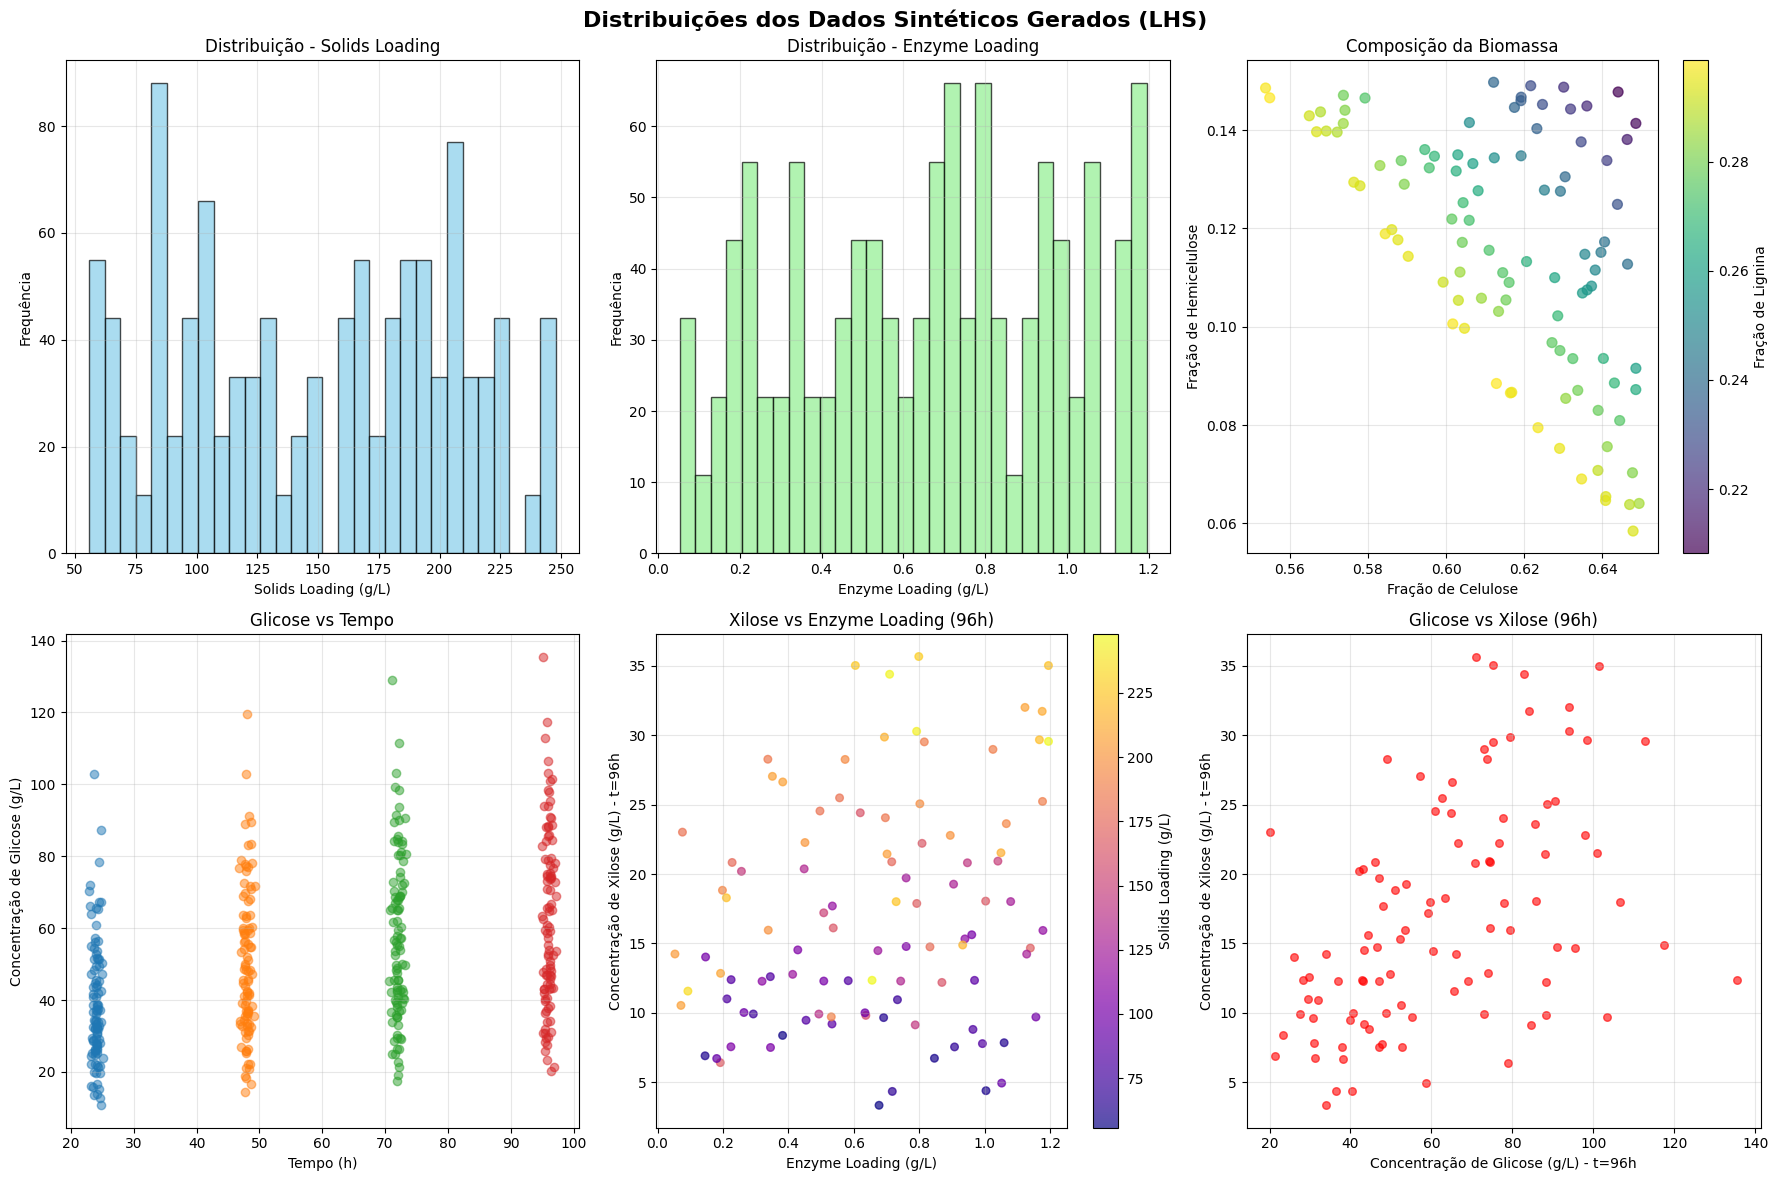

✓ Visualizações criadas


In [7]:
# ============================================================================
# 6. VISUALIZAÇÃO DOS DADOS GERADOS
# ============================================================================

print("\n5. CRIANDO VISUALIZAÇÕES...")

# Criar figura com múltiplos subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribuições dos Dados Sintéticos Gerados (LHS)', fontsize=16, fontweight='bold')

# 1. Distribuição de Solids Loading
axes[0,0].hist(synthetic_data['solids_loading'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel('Solids Loading (g/L)')
axes[0,0].set_ylabel('Frequência')
axes[0,0].set_title('Distribuição - Solids Loading')
axes[0,0].grid(True, alpha=0.3)

# 2. Distribuição de Enzyme Loading
axes[0,1].hist(synthetic_data['enzyme_loading'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].set_xlabel('Enzyme Loading (g/L)')
axes[0,1].set_ylabel('Frequência')
axes[0,1].set_title('Distribuição - Enzyme Loading')
axes[0,1].grid(True, alpha=0.3)

# 3. Composição da Biomassa
composition_data = synthetic_data[['cellulose_fraction', 'hemicellulose_fraction', 'lignin_fraction']].drop_duplicates()
axes[0,2].scatter(composition_data['cellulose_fraction'], composition_data['hemicellulose_fraction'], 
                  c=composition_data['lignin_fraction'], cmap='viridis', alpha=0.7, s=50)
cbar = plt.colorbar(axes[0,2].collections[0], ax=axes[0,2])
cbar.set_label('Fração de Lignina')
axes[0,2].set_xlabel('Fração de Celulose')
axes[0,2].set_ylabel('Fração de Hemicelulose')
axes[0,2].set_title('Composição da Biomassa')
axes[0,2].grid(True, alpha=0.3)

# 4. Concentração de Glicose vs Tempo
time_subset = synthetic_data[synthetic_data['time'].isin([24, 48, 72, 96])]
for t in [24, 48, 72, 96]:
    data_t = time_subset[time_subset['time'] == t]
    axes[1,0].scatter(data_t['time'] + np.random.normal(0, 0.5, len(data_t)), 
                      data_t['glucose_concentration'], alpha=0.5, label=f'{t}h')
axes[1,0].set_xlabel('Tempo (h)')
axes[1,0].set_ylabel('Concentração de Glicose (g/L)')
axes[1,0].set_title('Glicose vs Tempo')
axes[1,0].grid(True, alpha=0.3)

# 5. Concentração de Xilose vs Enzyme Loading
final_time_data = synthetic_data[synthetic_data['time'] == 96]
scatter = axes[1,1].scatter(final_time_data['enzyme_loading'], final_time_data['xylose_concentration'], 
                           c=final_time_data['solids_loading'], cmap='plasma', alpha=0.7, s=30)
cbar2 = plt.colorbar(scatter, ax=axes[1,1])
cbar2.set_label('Solids Loading (g/L)')
axes[1,1].set_xlabel('Enzyme Loading (g/L)')
axes[1,1].set_ylabel('Concentração de Xilose (g/L) - t=96h')
axes[1,1].set_title('Xilose vs Enzyme Loading (96h)')
axes[1,1].grid(True, alpha=0.3)

# 6. Correlação entre produtos (tempo final)
axes[1,2].scatter(final_time_data['glucose_concentration'], final_time_data['xylose_concentration'], 
                  alpha=0.6, s=30, c='red')
axes[1,2].set_xlabel('Concentração de Glicose (g/L) - t=96h')
axes[1,2].set_ylabel('Concentração de Xilose (g/L) - t=96h')
axes[1,2].set_title('Glicose vs Xilose (96h)')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizações criadas")

In [8]:
# ============================================================================
# 7. ANÁLISE DE QUALIDADE DOS DADOS
# ============================================================================

print("\n6. ANÁLISE DE QUALIDADE DOS DADOS...")

# Verificar valores faltantes
missing_data = synthetic_data.isnull().sum()
print(f"📊 VALORES FALTANTES:")
for col, count in missing_data.items():
    if count > 0:
        print(f"   • {col}: {count}")
    else:
        print(f"   ✓ {col}: 0")

# Verificar valores negativos (que não deveriam existir)
negative_check = {
    'glucose_concentration': (synthetic_data['glucose_concentration'] < 0).sum(),
    'xylose_concentration': (synthetic_data['xylose_concentration'] < 0).sum(),
    'cellobiose_concentration': (synthetic_data['cellobiose_concentration'] < 0).sum()
}

print(f"\n🔍 VERIFICAÇÃO DE VALORES NEGATIVOS:")
for col, count in negative_check.items():
    if count > 0:
        print(f"   ⚠️  {col}: {count} valores negativos")
    else:
        print(f"   ✓ {col}: sem valores negativos")

# Verificar restrição de composição (soma = 1)
composition_sum = synthetic_data['cellulose_fraction'] + synthetic_data['hemicellulose_fraction'] + synthetic_data['lignin_fraction']
composition_error = abs(composition_sum - 1.0)
max_composition_error = composition_error.max()

print(f"\n⚖️  VERIFICAÇÃO DE COMPOSIÇÃO:")
print(f"   • Erro máximo na soma das frações: {max_composition_error:.6f}")
if max_composition_error < 1e-10:
    print("   ✓ Composição correta (soma = 1.000)")
else:
    print("   ⚠️  Pequenos erros de arredondamento detectados")

# Verificar range de lignina
lignin_min = synthetic_data['lignin_fraction'].min()
lignin_max = synthetic_data['lignin_fraction'].max()
print(f"\n🌿 VERIFICAÇÃO DE LIGNINA:")
print(f"   • Range: {lignin_min:.3f} - {lignin_max:.3f}")
if 0.20 <= lignin_min and lignin_max <= 0.30:
    print("   ✓ Lignina dentro do range especificado (20-30%)")
else:
    print("   ⚠️  Lignina fora do range especificado")

# Estatísticas descritivas dos produtos
print(f"\n📈 ESTATÍSTICAS DOS PRODUTOS (g/L):")
print(f"   GLICOSE:")
print(f"     • Média: {synthetic_data['glucose_concentration'].mean():.2f}")
print(f"     • Desvio: {synthetic_data['glucose_concentration'].std():.2f}")
print(f"     • Range: {synthetic_data['glucose_concentration'].min():.2f} - {synthetic_data['glucose_concentration'].max():.2f}")

print(f"   XILOSE:")
print(f"     • Média: {synthetic_data['xylose_concentration'].mean():.2f}")
print(f"     • Desvio: {synthetic_data['xylose_concentration'].std():.2f}")
print(f"     • Range: {synthetic_data['xylose_concentration'].min():.2f} - {synthetic_data['xylose_concentration'].max():.2f}")

print(f"   CELOBIOSE:")
print(f"     • Média: {synthetic_data['cellobiose_concentration'].mean():.2f}")
print(f"     • Desvio: {synthetic_data['cellobiose_concentration'].std():.2f}")
print(f"     • Range: {synthetic_data['cellobiose_concentration'].min():.2f} - {synthetic_data['cellobiose_concentration'].max():.2f}")

# Análise por tempo
print(f"\n⏰ ANÁLISE POR TEMPO:")
for t in [0, 24, 48, 96]:
    data_t = synthetic_data[synthetic_data['time'] == t]
    glucose_mean = data_t['glucose_concentration'].mean()
    print(f"   • t={t:2d}h: Glicose média = {glucose_mean:.2f} g/L")


6. ANÁLISE DE QUALIDADE DOS DADOS...
📊 VALORES FALTANTES:
   ✓ cellulose_fraction: 0
   ✓ hemicellulose_fraction: 0
   ✓ lignin_fraction: 0
   ✓ solids_loading: 0
   ✓ enzyme_loading: 0
   ✓ time: 0
   ✓ glucose_concentration: 0
   ✓ xylose_concentration: 0
   ✓ cellobiose_concentration: 0

🔍 VERIFICAÇÃO DE VALORES NEGATIVOS:
   ✓ glucose_concentration: sem valores negativos
   ✓ xylose_concentration: sem valores negativos
   ✓ cellobiose_concentration: sem valores negativos

⚖️  VERIFICAÇÃO DE COMPOSIÇÃO:
   • Erro máximo na soma das frações: 0.000000
   ✓ Composição correta (soma = 1.000)

🌿 VERIFICAÇÃO DE LIGNINA:
   • Range: 0.208 - 0.299
   ✓ Lignina dentro do range especificado (20-30%)

📈 ESTATÍSTICAS DOS PRODUTOS (g/L):
   GLICOSE:
     • Média: 30.27
     • Desvio: 24.16
     • Range: 0.00 - 135.56
   XILOSE:
     • Média: 10.92
     • Desvio: 8.29
     • Range: 0.00 - 35.67
   CELOBIOSE:
     • Média: 1.22
     • Desvio: 1.13
     • Range: 0.00 - 5.57

⏰ ANÁLISE POR TEMPO:
 

In [9]:
# ============================================================================
# 8. EXPORTAÇÃO DOS DADOS SINTÉTICOS
# ============================================================================

print("\n7. EXPORTANDO DADOS...")

# Reordenar colunas para ficar igual aos dados experimentais
final_columns = [
    'cellulose_fraction',
    'hemicellulose_fraction', 
    'lignin_fraction',
    'solids_loading',
    'enzyme_loading',
    'time',
    'glucose_concentration',
    'xylose_concentration',
    'cellobiose_concentration'
]

# Reorganizar DataFrame
synthetic_data_final = synthetic_data[final_columns].copy()

# Renomear colunas para ficar padronizado
synthetic_data_final.columns = [
    'Cellulose',
    'Hemicellulose',
    'Lignin', 
    'Solids Loading [g/L]',
    'Enzyme Loading [g/L]',
    'Time [h]',
    'Glucose Concentration [g/L]',
    'Xylose Concentration [g/L]',
    'Cellobiose Concentration [g/L]'
]

# Salvar em CSV
output_filename = 'synthetic_hydrolysis_data_LHS.csv'
synthetic_data_final.to_csv(output_filename, index=False, float_format='%.3f')

print(f"✓ Dados salvos em: {output_filename}")
print(f"✓ Total de amostras: {len(synthetic_data_final)}")

# Mostrar primeiras linhas
print(f"\n📋 PRIMEIRAS 10 LINHAS DOS DADOS FINAIS:")
print(synthetic_data_final.head(10).to_string(index=False))

print(f"\n📋 ÚLTIMAS 5 LINHAS DOS DADOS FINAIS:")
print(synthetic_data_final.tail(5).to_string(index=False))

# ============================================================================
# RESUMO FINAL
# ============================================================================

print("\n" + "=" * 80)
print("GERAÇÃO DE DADOS SINTÉTICOS CONCLUÍDA COM SUCESSO! ✓")
print("=" * 80)

print(f"\n📊 RESUMO DA GERAÇÃO:")
print(f"   • Método: Latin Hypercube Sampling (LHS)")
print(f"   • Condições únicas: {len(conditions_df)}")
print(f"   • Tempos por condição: {len(time_points)}")
print(f"   • Total de amostras: {len(synthetic_data_final)}")
print(f"   • Arquivo gerado: {output_filename}")

print(f"\n🎯 PARÂMETROS VARIADOS:")
print(f"   • Solids Loading: {param_ranges['solids_loading'][0]:.0f}-{param_ranges['solids_loading'][1]:.0f} g/L")
print(f"   • Enzyme Loading: {param_ranges['enzyme_loading'][0]:.2f}-{param_ranges['enzyme_loading'][1]:.2f} g/L")
print(f"   • Celulose: {param_ranges['cellulose_fraction'][0]*100:.0f}-{param_ranges['cellulose_fraction'][1]*100:.0f}%")
print(f"   • Hemicelulose: {param_ranges['hemicellulose_fraction'][0]*100:.0f}-{param_ranges['hemicellulose_fraction'][1]*100:.0f}%")
print(f"   • Lignina: 20-30% (calculada automaticamente)")
print(f"   • Tempo: 0-96h ({len(time_points)} pontos)")

print(f"\n🔬 PRODUTOS SIMULADOS:")
print(f"   • Glicose: 0-{synthetic_data_final['Glucose Concentration [g/L]'].max():.1f} g/L")
print(f"   • Xilose: 0-{synthetic_data_final['Xylose Concentration [g/L]'].max():.1f} g/L")
print(f"   • Celobiose: 0-{synthetic_data_final['Cellobiose Concentration [g/L]'].max():.1f} g/L")

print(f"\n✅ Os dados estão prontos para serem usados em:")
print(f"   • Treinamento de modelos de machine learning")
print(f"   • Análise de sensibilidade")
print(f"   • Otimização de processos")
print(f"   • Validação de modelos")

print("\n" + "=" * 80)


7. EXPORTANDO DADOS...
✓ Dados salvos em: synthetic_hydrolysis_data_LHS.csv
✓ Total de amostras: 1100

📋 PRIMEIRAS 10 LINHAS DOS DADOS FINAIS:
 Cellulose  Hemicellulose   Lignin  Solids Loading [g/L]  Enzyme Loading [g/L]  Time [h]  Glucose Concentration [g/L]  Xylose Concentration [g/L]  Cellobiose Concentration [g/L]
  0.599258       0.109073 0.291668            119.743773              0.412821         0                     0.000000                    0.000000                        0.000000
  0.599258       0.109073 0.291668            119.743773              0.412821         1                     9.305407                    2.833722                        0.478600
  0.599258       0.109073 0.291668            119.743773              0.412821         2                    11.974592                    4.228145                        0.671585
  0.599258       0.109073 0.291668            119.743773              0.412821         4                    15.415584                    5.93565

In [10]:
synthetic_data_final

,Cellulose,Hemicellulose,Lignin,Solids Loading [g/L],Enzyme Loading [g/L],Time [h],Glucose Concentration [g/L],Xylose Concentration [g/L],Cellobiose Concentration [g/L]
0,0.599258,0.109073,0.291668,119.743773,0.412821,0,0.000000,0.000000,0.000000
1,0.599258,0.109073,0.291668,119.743773,0.412821,1,9.305407,2.833722,0.478600
2,0.599258,0.109073,0.291668,119.743773,0.412821,2,11.974592,4.228145,0.671585
3,0.599258,0.109073,0.291668,119.743773,0.412821,4,15.415584,5.935654,0.902717
4,0.599258,0.109073,0.291668,119.743773,0.412821,6,17.919486,7.014915,1.044932
...,...,...,...,...,...,...,...,...,...
1095,0.604720,0.099682,0.295597,222.100230,0.210352,12,28.715044,9.920768,1.925267
1096,0.604720,0.099682,0.295597,222.100230,0.210352,24,37.273159,12.886552,2.555933
1097,0.604720,0.099682,0.295597,222.100230,0.210352,48,48.615843,15.766020,3.197655
1098,0.604720,0.099682,0.295597,222.100230,0.210352,72,56.769826,17.297463,3.495654



8. CRIANDO ANÁLISE GRÁFICA DETALHADA...


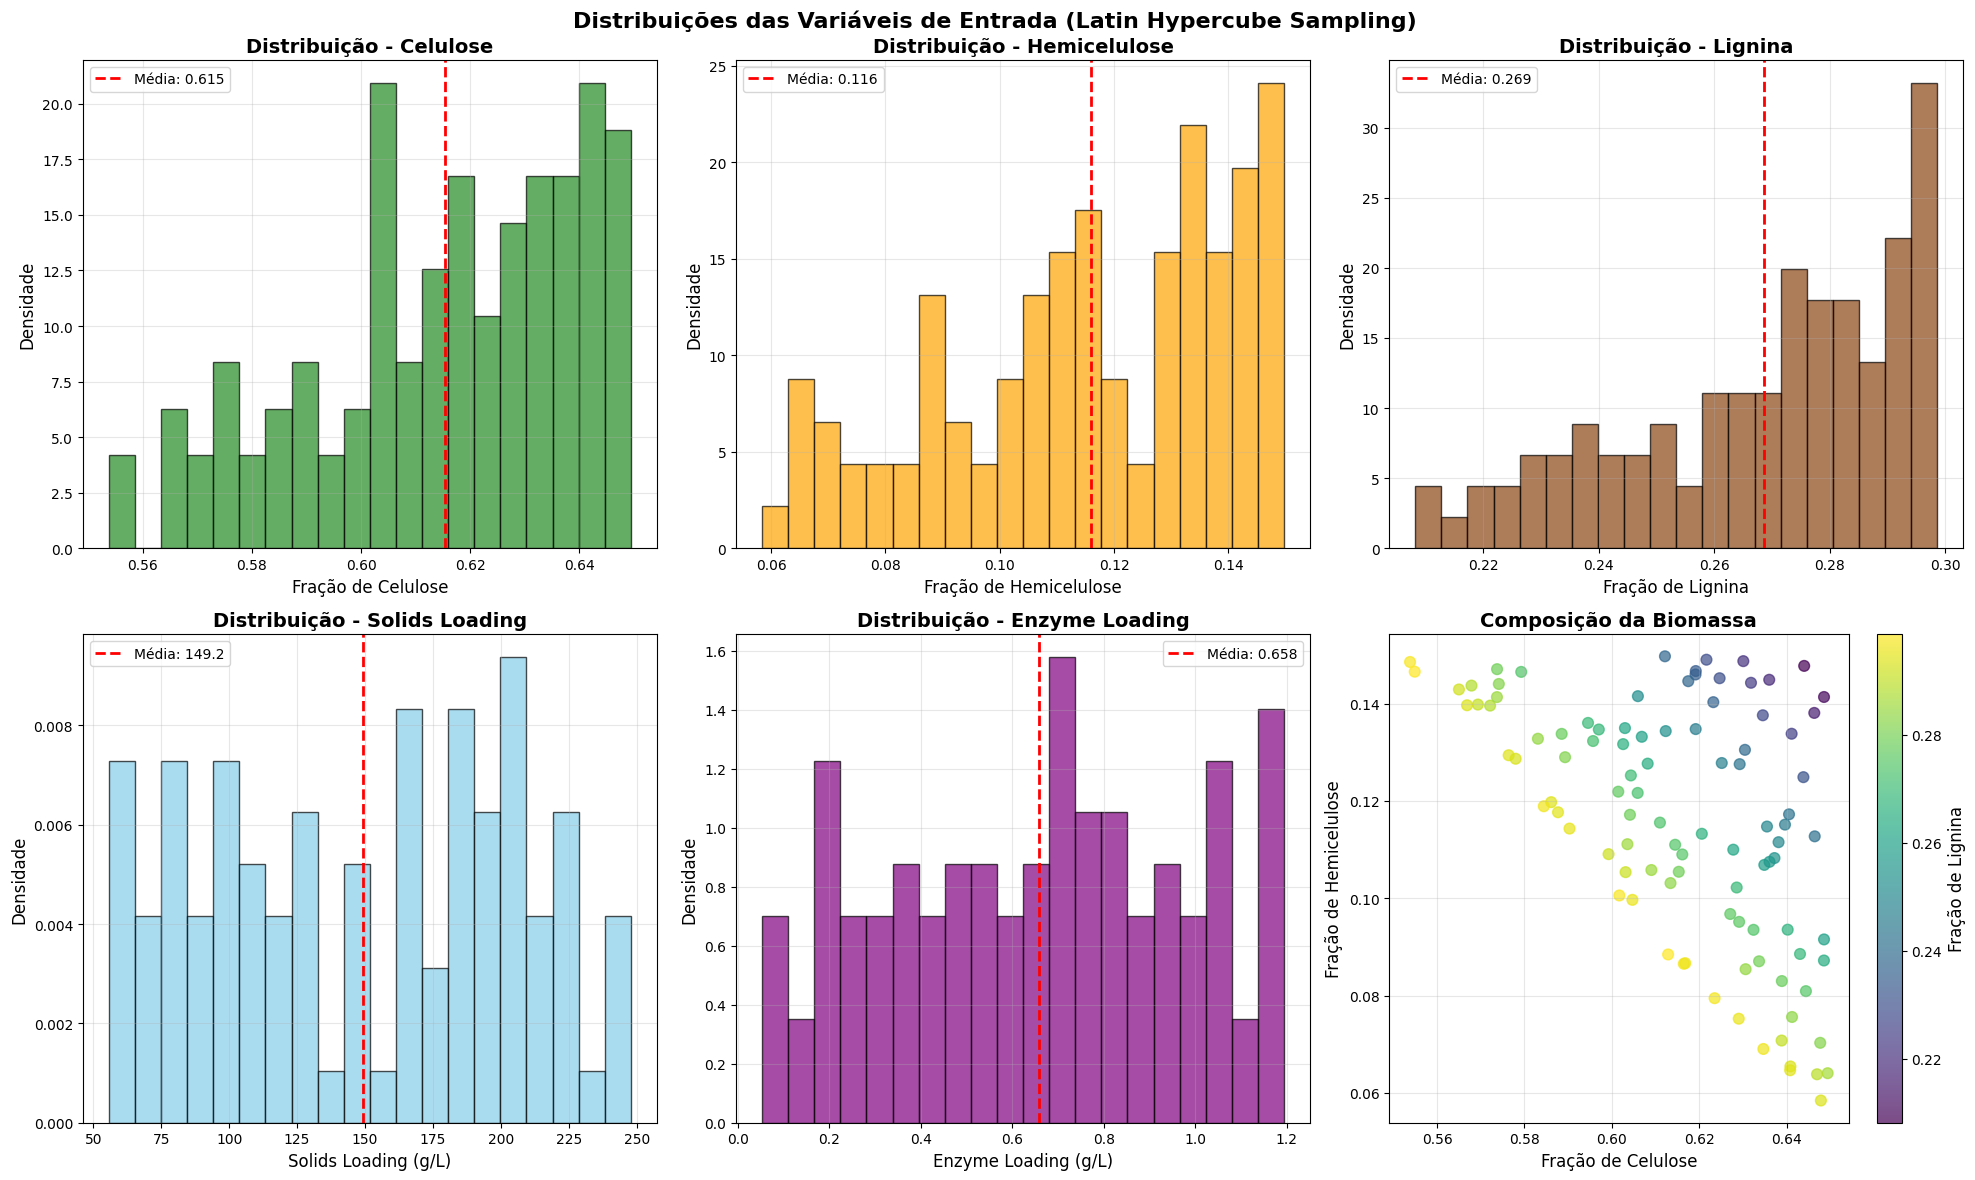

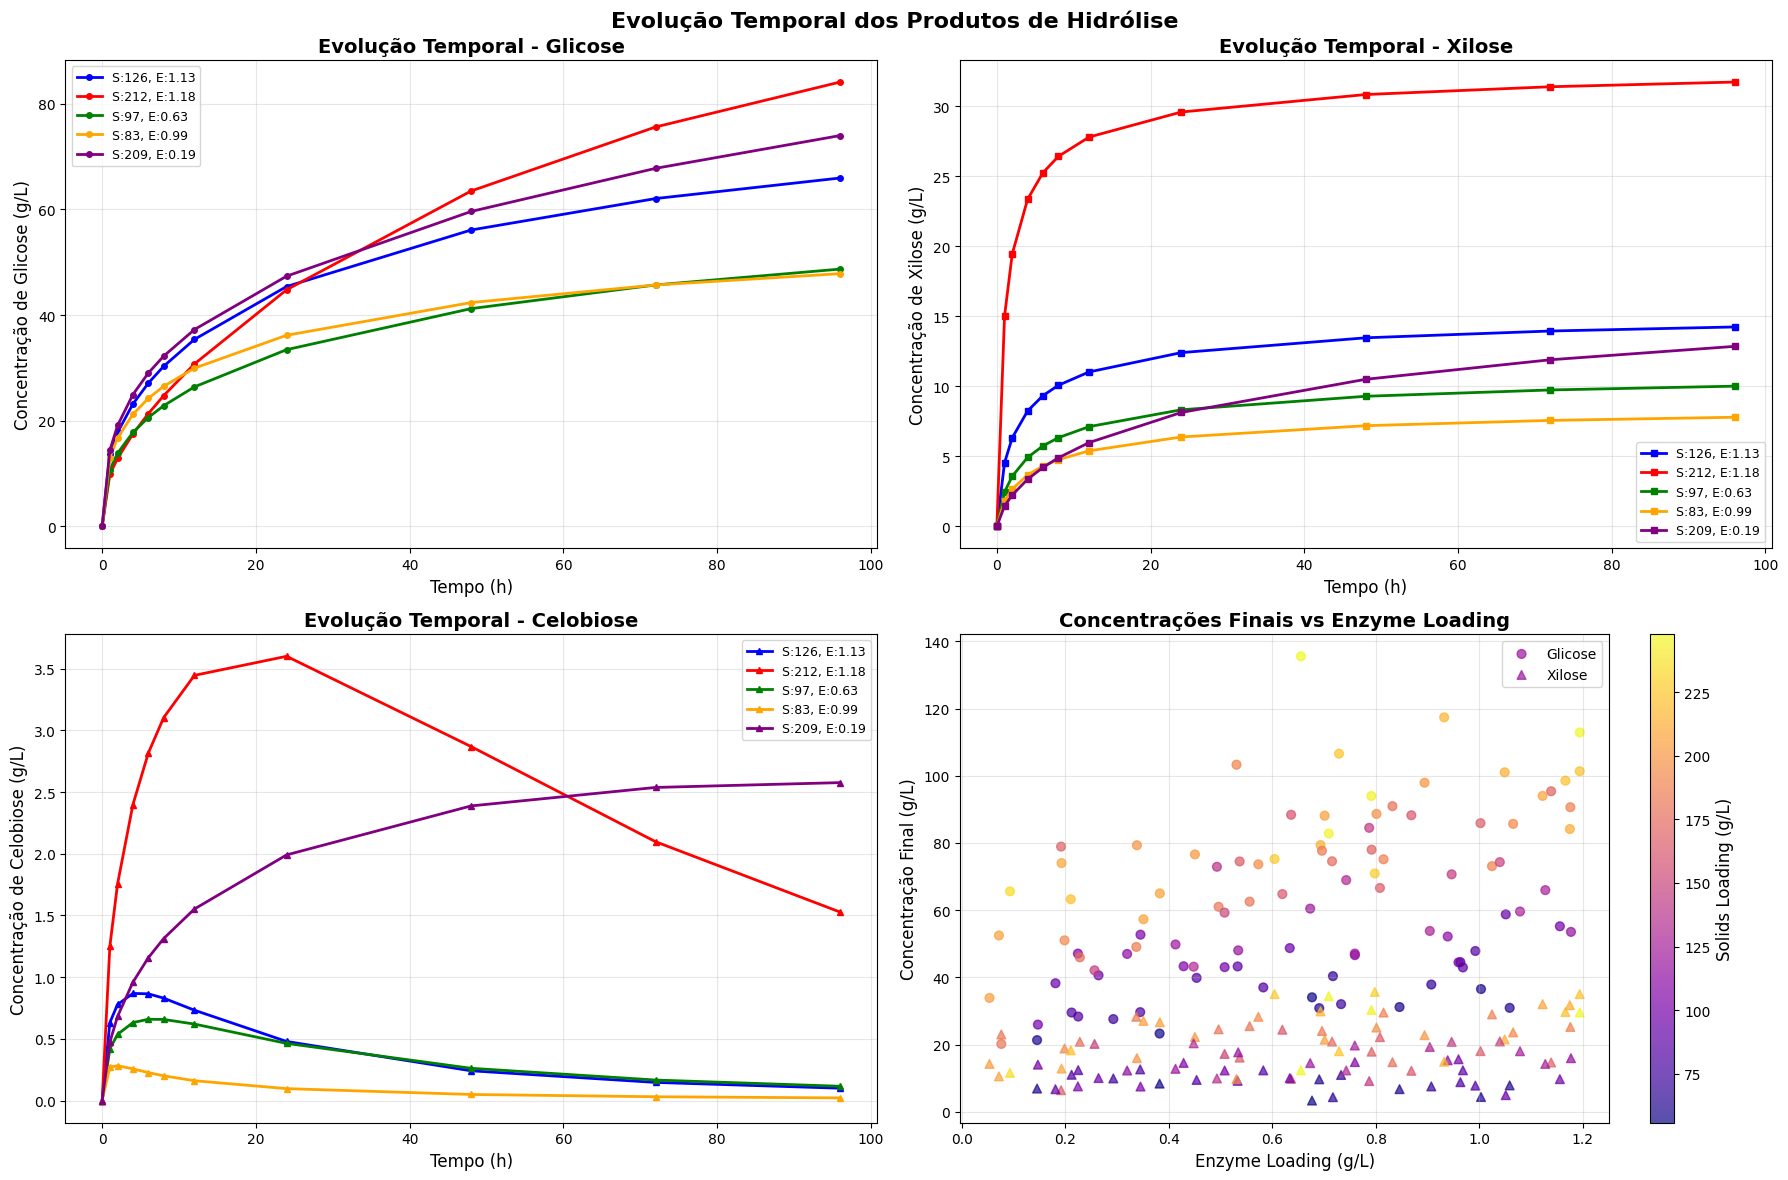

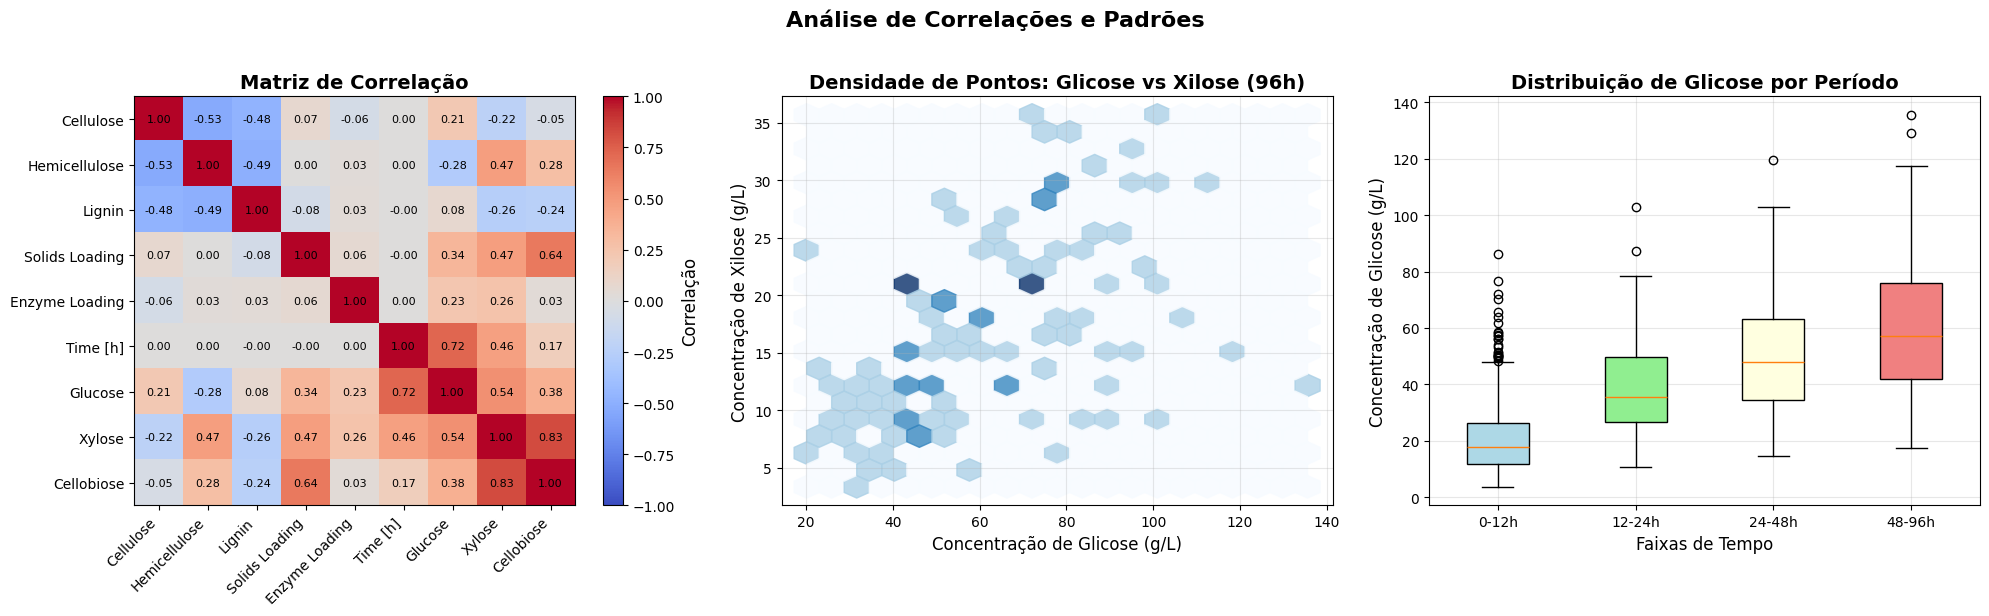


📊 ESTATÍSTICAS RESUMO DOS DADOS SINTÉTICOS:
📈 VARIÁVEIS DE ENTRADA:
   • Celulose: 0.554 - 0.649 (Std: 0.025)
   • Hemicelulose: 0.058 - 0.150 (Std: 0.025)
   • Lignina: 0.208 - 0.299 (Std: 0.024)
   • Solids Loading: 55.7 - 247.9 g/L (Std: 55.9)
   • Enzyme Loading: 0.053 - 1.195 g/L (Std: 0.324)

🔬 PRODUTOS (TODAS AS AMOSTRAS):
   • Glicose: 0.00 - 135.56 g/L (Média: 30.27)
   • Xilose: 0.00 - 35.67 g/L (Média: 10.92)
   • Celobiose: 0.00 - 5.57 g/L (Média: 1.22)

🎯 PRODUTOS FINAIS (t=96h):
   • Glicose: 20.18 - 135.56 g/L (Média: 62.38)
   • Xilose: 3.34 - 35.67 g/L (Média: 17.01)
   • Celobiose: 0.00 - 5.25 g/L (Média: 1.29)

✅ Análise gráfica concluída! Os gráficos mostram a qualidade e distribuição dos dados LHS.


In [11]:
# ============================================================================
# 9. ANÁLISE GRÁFICA DETALHADA DOS DADOS SINTÉTICOS
# ============================================================================

print("\n8. CRIANDO ANÁLISE GRÁFICA DETALHADA...")

# Configurar estilo dos gráficos
plt.style.use('default')

# ============================================================================
# GRÁFICO 1: DISTRIBUIÇÕES MARGINAIS DAS VARIÁVEIS DE ENTRADA
# ============================================================================

fig1, axes1 = plt.subplots(2, 3, figsize=(20, 12))
fig1.suptitle('Distribuições das Variáveis de Entrada (Latin Hypercube Sampling)', 
              fontsize=16, fontweight='bold', y=0.98)

# Dados únicos das condições (sem repetir por tempo)
unique_conditions = synthetic_data_final.drop_duplicates(
    subset=['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]']
)

# 1.1 Distribuição de Celulose
axes1[0,0].hist(unique_conditions['Cellulose'], bins=20, alpha=0.7, color='forestgreen', 
                edgecolor='black', density=True)
axes1[0,0].axvline(unique_conditions['Cellulose'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Média: {unique_conditions["Cellulose"].mean():.3f}')
axes1[0,0].set_xlabel('Fração de Celulose', fontsize=12)
axes1[0,0].set_ylabel('Densidade', fontsize=12)
axes1[0,0].set_title('Distribuição - Celulose', fontsize=14, fontweight='bold')
axes1[0,0].grid(True, alpha=0.3)
axes1[0,0].legend()

# 1.2 Distribuição de Hemicelulose
axes1[0,1].hist(unique_conditions['Hemicellulose'], bins=20, alpha=0.7, color='orange', 
                edgecolor='black', density=True)
axes1[0,1].axvline(unique_conditions['Hemicellulose'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Média: {unique_conditions["Hemicellulose"].mean():.3f}')
axes1[0,1].set_xlabel('Fração de Hemicelulose', fontsize=12)
axes1[0,1].set_ylabel('Densidade', fontsize=12)
axes1[0,1].set_title('Distribuição - Hemicelulose', fontsize=14, fontweight='bold')
axes1[0,1].grid(True, alpha=0.3)
axes1[0,1].legend()

# 1.3 Distribuição de Lignina
axes1[0,2].hist(unique_conditions['Lignin'], bins=20, alpha=0.7, color='saddlebrown', 
                edgecolor='black', density=True)
axes1[0,2].axvline(unique_conditions['Lignin'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Média: {unique_conditions["Lignin"].mean():.3f}')
axes1[0,2].set_xlabel('Fração de Lignina', fontsize=12)
axes1[0,2].set_ylabel('Densidade', fontsize=12)
axes1[0,2].set_title('Distribuição - Lignina', fontsize=14, fontweight='bold')
axes1[0,2].grid(True, alpha=0.3)
axes1[0,2].legend()

# 1.4 Distribuição de Solids Loading
axes1[1,0].hist(unique_conditions['Solids Loading [g/L]'], bins=20, alpha=0.7, color='skyblue', 
                edgecolor='black', density=True)
axes1[1,0].axvline(unique_conditions['Solids Loading [g/L]'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Média: {unique_conditions["Solids Loading [g/L]"].mean():.1f}')
axes1[1,0].set_xlabel('Solids Loading (g/L)', fontsize=12)
axes1[1,0].set_ylabel('Densidade', fontsize=12)
axes1[1,0].set_title('Distribuição - Solids Loading', fontsize=14, fontweight='bold')
axes1[1,0].grid(True, alpha=0.3)
axes1[1,0].legend()

# 1.5 Distribuição de Enzyme Loading
axes1[1,1].hist(unique_conditions['Enzyme Loading [g/L]'], bins=20, alpha=0.7, color='purple', 
                edgecolor='black', density=True)
axes1[1,1].axvline(unique_conditions['Enzyme Loading [g/L]'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Média: {unique_conditions["Enzyme Loading [g/L]"].mean():.3f}')
axes1[1,1].set_xlabel('Enzyme Loading (g/L)', fontsize=12)
axes1[1,1].set_ylabel('Densidade', fontsize=12)
axes1[1,1].set_title('Distribuição - Enzyme Loading', fontsize=14, fontweight='bold')
axes1[1,1].grid(True, alpha=0.3)
axes1[1,1].legend()

# 1.6 Correlação Celulose vs Hemicelulose (colorida por Lignina)
scatter = axes1[1,2].scatter(unique_conditions['Cellulose'], unique_conditions['Hemicellulose'], 
                           c=unique_conditions['Lignin'], cmap='viridis', alpha=0.7, s=60)
cbar = plt.colorbar(scatter, ax=axes1[1,2])
cbar.set_label('Fração de Lignina', fontsize=12)
axes1[1,2].set_xlabel('Fração de Celulose', fontsize=12)
axes1[1,2].set_ylabel('Fração de Hemicelulose', fontsize=12)
axes1[1,2].set_title('Composição da Biomassa', fontsize=14, fontweight='bold')
axes1[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# GRÁFICO 2: EVOLUÇÃO TEMPORAL DOS PRODUTOS
# ============================================================================

fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
fig2.suptitle('Evolução Temporal dos Produtos de Hidrólise', 
              fontsize=16, fontweight='bold', y=0.98)

# Selecionar algumas condições para visualizar a evolução temporal
sample_conditions = unique_conditions.sample(n=5, random_state=42)

colors = ['blue', 'red', 'green', 'orange', 'purple']

# 2.1 Evolução da Glicose
for i, (idx, condition) in enumerate(sample_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes2[0,0].plot(condition_data['Time [h]'], condition_data['Glucose Concentration [g/L]'], 
                   marker='o', color=colors[i], linewidth=2, markersize=4,
                   label=f'S:{condition["Solids Loading [g/L]"]:.0f}, E:{condition["Enzyme Loading [g/L]"]:.2f}')

axes2[0,0].set_xlabel('Tempo (h)', fontsize=12)
axes2[0,0].set_ylabel('Concentração de Glicose (g/L)', fontsize=12)
axes2[0,0].set_title('Evolução Temporal - Glicose', fontsize=14, fontweight='bold')
axes2[0,0].grid(True, alpha=0.3)
axes2[0,0].legend(fontsize=9)

# 2.2 Evolução da Xilose
for i, (idx, condition) in enumerate(sample_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes2[0,1].plot(condition_data['Time [h]'], condition_data['Xylose Concentration [g/L]'], 
                   marker='s', color=colors[i], linewidth=2, markersize=4,
                   label=f'S:{condition["Solids Loading [g/L]"]:.0f}, E:{condition["Enzyme Loading [g/L]"]:.2f}')

axes2[0,1].set_xlabel('Tempo (h)', fontsize=12)
axes2[0,1].set_ylabel('Concentração de Xilose (g/L)', fontsize=12)
axes2[0,1].set_title('Evolução Temporal - Xilose', fontsize=14, fontweight='bold')
axes2[0,1].grid(True, alpha=0.3)
axes2[0,1].legend(fontsize=9)

# 2.3 Evolução da Celobiose
for i, (idx, condition) in enumerate(sample_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes2[1,0].plot(condition_data['Time [h]'], condition_data['Cellobiose Concentration [g/L]'], 
                   marker='^', color=colors[i], linewidth=2, markersize=4,
                   label=f'S:{condition["Solids Loading [g/L]"]:.0f}, E:{condition["Enzyme Loading [g/L]"]:.2f}')

axes2[1,0].set_xlabel('Tempo (h)', fontsize=12)
axes2[1,0].set_ylabel('Concentração de Celobiose (g/L)', fontsize=12)
axes2[1,0].set_title('Evolução Temporal - Celobiose', fontsize=14, fontweight='bold')
axes2[1,0].grid(True, alpha=0.3)
axes2[1,0].legend(fontsize=9)

# 2.4 Concentrações finais (t=96h) vs Enzyme Loading
final_data = synthetic_data_final[synthetic_data_final['Time [h]'] == 96]
scatter1 = axes2[1,1].scatter(final_data['Enzyme Loading [g/L]'], final_data['Glucose Concentration [g/L]'], 
                            c=final_data['Solids Loading [g/L]'], cmap='plasma', alpha=0.7, s=40, label='Glicose')
axes2[1,1].scatter(final_data['Enzyme Loading [g/L]'], final_data['Xylose Concentration [g/L]'], 
                  c=final_data['Solids Loading [g/L]'], cmap='plasma', alpha=0.7, s=40, marker='^', label='Xilose')

cbar2 = plt.colorbar(scatter1, ax=axes2[1,1])
cbar2.set_label('Solids Loading (g/L)', fontsize=12)
axes2[1,1].set_xlabel('Enzyme Loading (g/L)', fontsize=12)
axes2[1,1].set_ylabel('Concentração Final (g/L)', fontsize=12)
axes2[1,1].set_title('Concentrações Finais vs Enzyme Loading', fontsize=14, fontweight='bold')
axes2[1,1].grid(True, alpha=0.3)
axes2[1,1].legend()

plt.tight_layout()
plt.show()

# ============================================================================
# GRÁFICO 3: HEATMAPS E CORRELAÇÕES
# ============================================================================

fig3, axes3 = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle('Análise de Correlações e Padrões', fontsize=16, fontweight='bold', y=1.02)

# 3.1 Heatmap de Correlação
correlation_data = synthetic_data_final[['Cellulose', 'Hemicellulose', 'Lignin', 
                                       'Solids Loading [g/L]', 'Enzyme Loading [g/L]', 'Time [h]',
                                       'Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 
                                       'Cellobiose Concentration [g/L]']].corr()

im1 = axes3[0].imshow(correlation_data, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes3[0].set_xticks(range(len(correlation_data.columns)))
axes3[0].set_yticks(range(len(correlation_data.columns)))
axes3[0].set_xticklabels([col.replace(' [g/L]', '').replace(' Concentration', '') for col in correlation_data.columns], 
                        rotation=45, ha='right')
axes3[0].set_yticklabels([col.replace(' [g/L]', '').replace(' Concentration', '') for col in correlation_data.columns])
axes3[0].set_title('Matriz de Correlação', fontsize=14, fontweight='bold')

# Adicionar valores na matriz
for i in range(len(correlation_data)):
    for j in range(len(correlation_data.columns)):
        text = axes3[0].text(j, i, f'{correlation_data.iloc[i, j]:.2f}', 
                           ha="center", va="center", color="black", fontsize=8)

cbar3 = plt.colorbar(im1, ax=axes3[0])
cbar3.set_label('Correlação', fontsize=12)

# 3.2 Distribuição de produtos no tempo final
final_data = synthetic_data_final[synthetic_data_final['Time [h]'] == 96]
axes3[1].hexbin(final_data['Glucose Concentration [g/L]'], final_data['Xylose Concentration [g/L]'], 
               gridsize=20, cmap='Blues', alpha=0.8)
axes3[1].set_xlabel('Concentração de Glicose (g/L)', fontsize=12)
axes3[1].set_ylabel('Concentração de Xilose (g/L)', fontsize=12)
axes3[1].set_title('Densidade de Pontos: Glicose vs Xilose (96h)', fontsize=14, fontweight='bold')
axes3[1].grid(True, alpha=0.3)

# 3.3 Boxplot dos produtos por faixas de tempo
time_bins = [0, 12, 24, 48, 96]
time_labels = ['0-12h', '12-24h', '24-48h', '48-96h']

glucose_by_time = []
for i in range(len(time_bins)-1):
    time_data = synthetic_data_final[
        (synthetic_data_final['Time [h]'] > time_bins[i]) & 
        (synthetic_data_final['Time [h]'] <= time_bins[i+1])
    ]
    glucose_by_time.append(time_data['Glucose Concentration [g/L]'].values)

box_plot = axes3[2].boxplot(glucose_by_time, labels=time_labels, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

axes3[2].set_xlabel('Faixas de Tempo', fontsize=12)
axes3[2].set_ylabel('Concentração de Glicose (g/L)', fontsize=12)
axes3[2].set_title('Distribuição de Glicose por Período', fontsize=14, fontweight='bold')
axes3[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# ESTATÍSTICAS RESUMO
# ============================================================================

print("\n📊 ESTATÍSTICAS RESUMO DOS DADOS SINTÉTICOS:")
print("=" * 60)

print(f"📈 VARIÁVEIS DE ENTRADA:")
print(f"   • Celulose: {unique_conditions['Cellulose'].min():.3f} - {unique_conditions['Cellulose'].max():.3f} (Std: {unique_conditions['Cellulose'].std():.3f})")
print(f"   • Hemicelulose: {unique_conditions['Hemicellulose'].min():.3f} - {unique_conditions['Hemicellulose'].max():.3f} (Std: {unique_conditions['Hemicellulose'].std():.3f})")
print(f"   • Lignina: {unique_conditions['Lignin'].min():.3f} - {unique_conditions['Lignin'].max():.3f} (Std: {unique_conditions['Lignin'].std():.3f})")
print(f"   • Solids Loading: {unique_conditions['Solids Loading [g/L]'].min():.1f} - {unique_conditions['Solids Loading [g/L]'].max():.1f} g/L (Std: {unique_conditions['Solids Loading [g/L]'].std():.1f})")
print(f"   • Enzyme Loading: {unique_conditions['Enzyme Loading [g/L]'].min():.3f} - {unique_conditions['Enzyme Loading [g/L]'].max():.3f} g/L (Std: {unique_conditions['Enzyme Loading [g/L]'].std():.3f})")

print(f"\n🔬 PRODUTOS (TODAS AS AMOSTRAS):")
print(f"   • Glicose: {synthetic_data_final['Glucose Concentration [g/L]'].min():.2f} - {synthetic_data_final['Glucose Concentration [g/L]'].max():.2f} g/L (Média: {synthetic_data_final['Glucose Concentration [g/L]'].mean():.2f})")
print(f"   • Xilose: {synthetic_data_final['Xylose Concentration [g/L]'].min():.2f} - {synthetic_data_final['Xylose Concentration [g/L]'].max():.2f} g/L (Média: {synthetic_data_final['Xylose Concentration [g/L]'].mean():.2f})")
print(f"   • Celobiose: {synthetic_data_final['Cellobiose Concentration [g/L]'].min():.2f} - {synthetic_data_final['Cellobiose Concentration [g/L]'].max():.2f} g/L (Média: {synthetic_data_final['Cellobiose Concentration [g/L]'].mean():.2f})")

final_data = synthetic_data_final[synthetic_data_final['Time [h]'] == 96]
print(f"\n🎯 PRODUTOS FINAIS (t=96h):")
print(f"   • Glicose: {final_data['Glucose Concentration [g/L]'].min():.2f} - {final_data['Glucose Concentration [g/L]'].max():.2f} g/L (Média: {final_data['Glucose Concentration [g/L]'].mean():.2f})")
print(f"   • Xilose: {final_data['Xylose Concentration [g/L]'].min():.2f} - {final_data['Xylose Concentration [g/L]'].max():.2f} g/L (Média: {final_data['Xylose Concentration [g/L]'].mean():.2f})")
print(f"   • Celobiose: {final_data['Cellobiose Concentration [g/L]'].min():.2f} - {final_data['Cellobiose Concentration [g/L]'].max():.2f} g/L (Média: {final_data['Cellobiose Concentration [g/L]'].mean():.2f})")

print("\n✅ Análise gráfica concluída! Os gráficos mostram a qualidade e distribuição dos dados LHS.")


9. CRIANDO GRÁFICOS DE EVOLUÇÃO TEMPORAL PARA MÚLTIPLAS CONDIÇÕES...


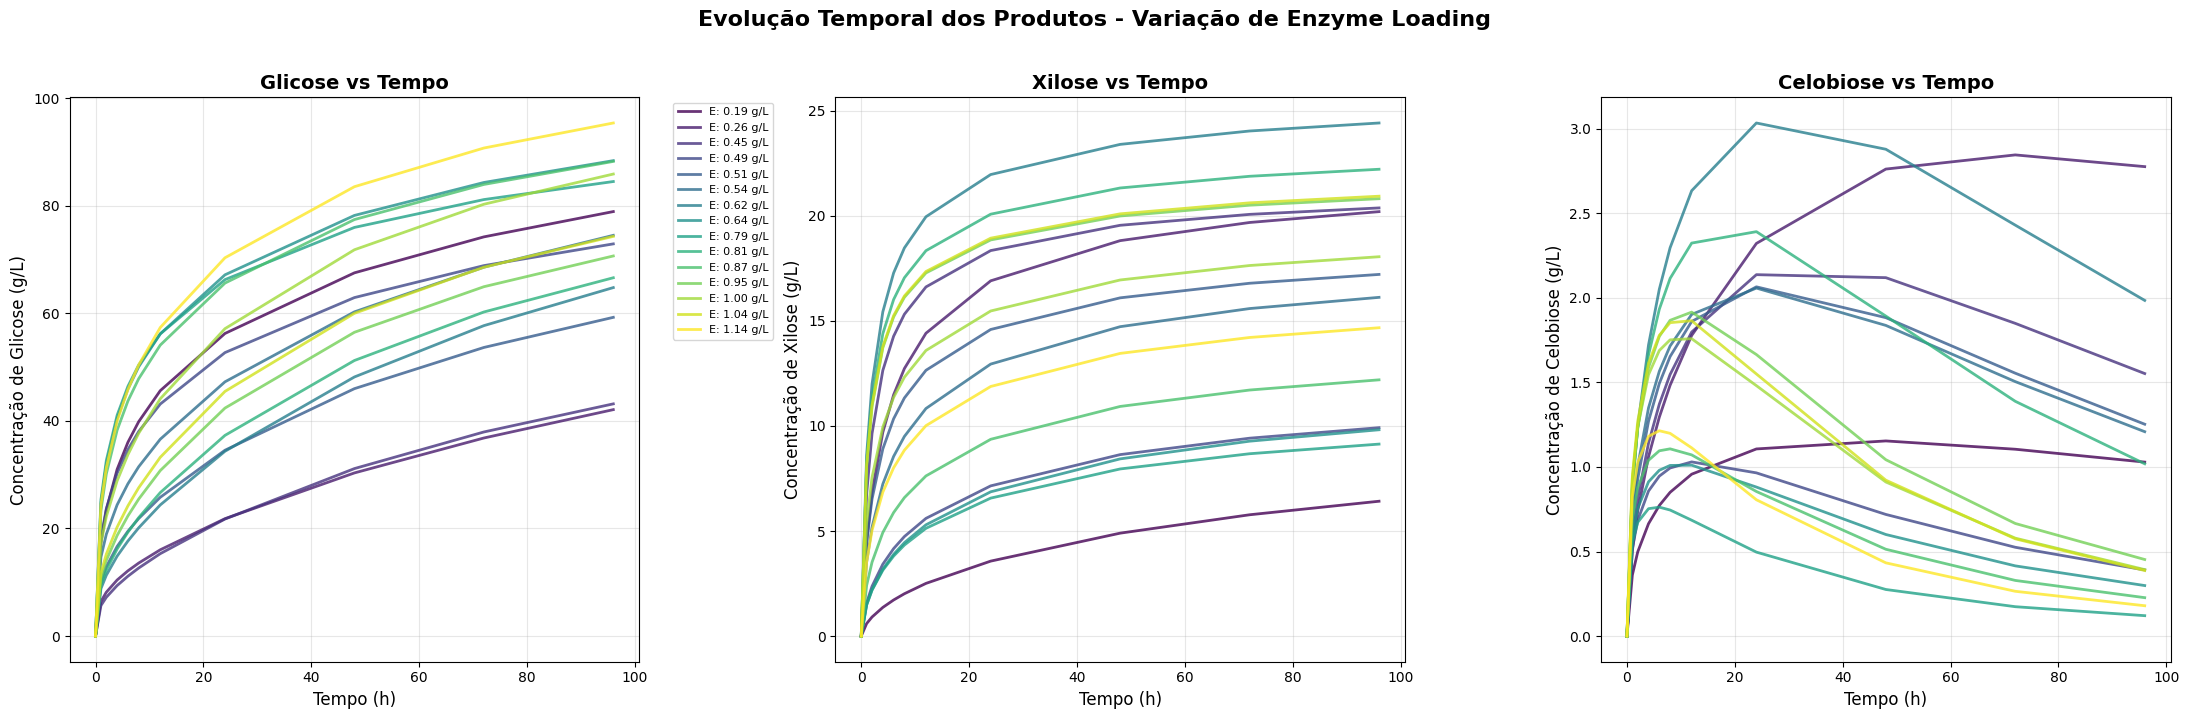

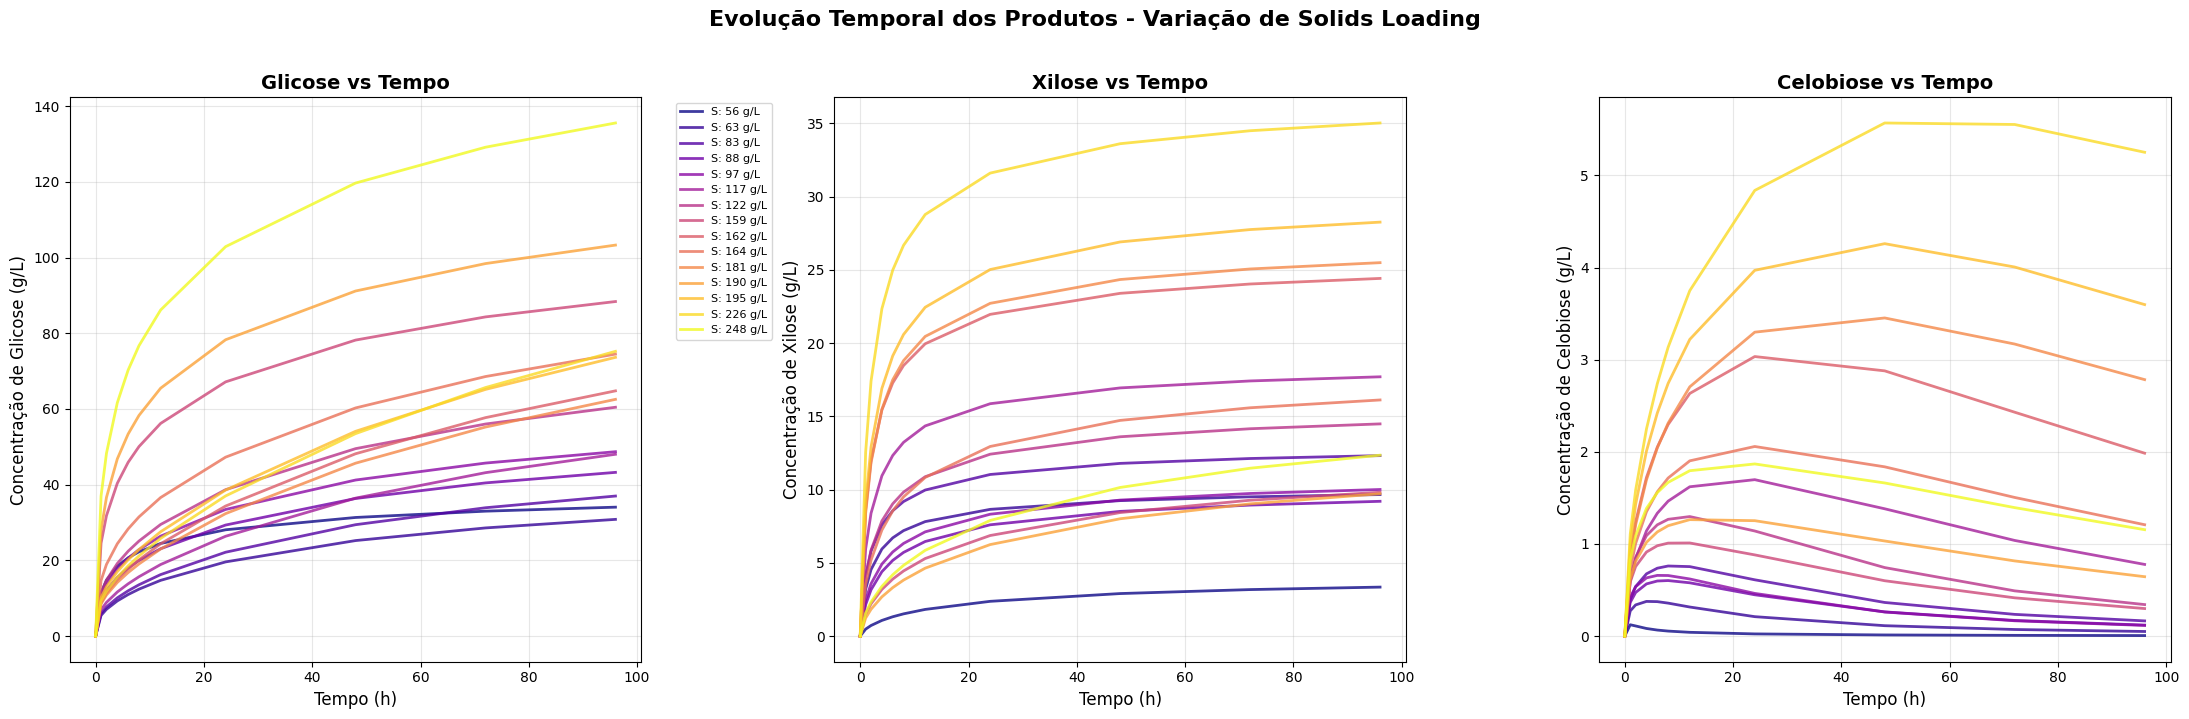

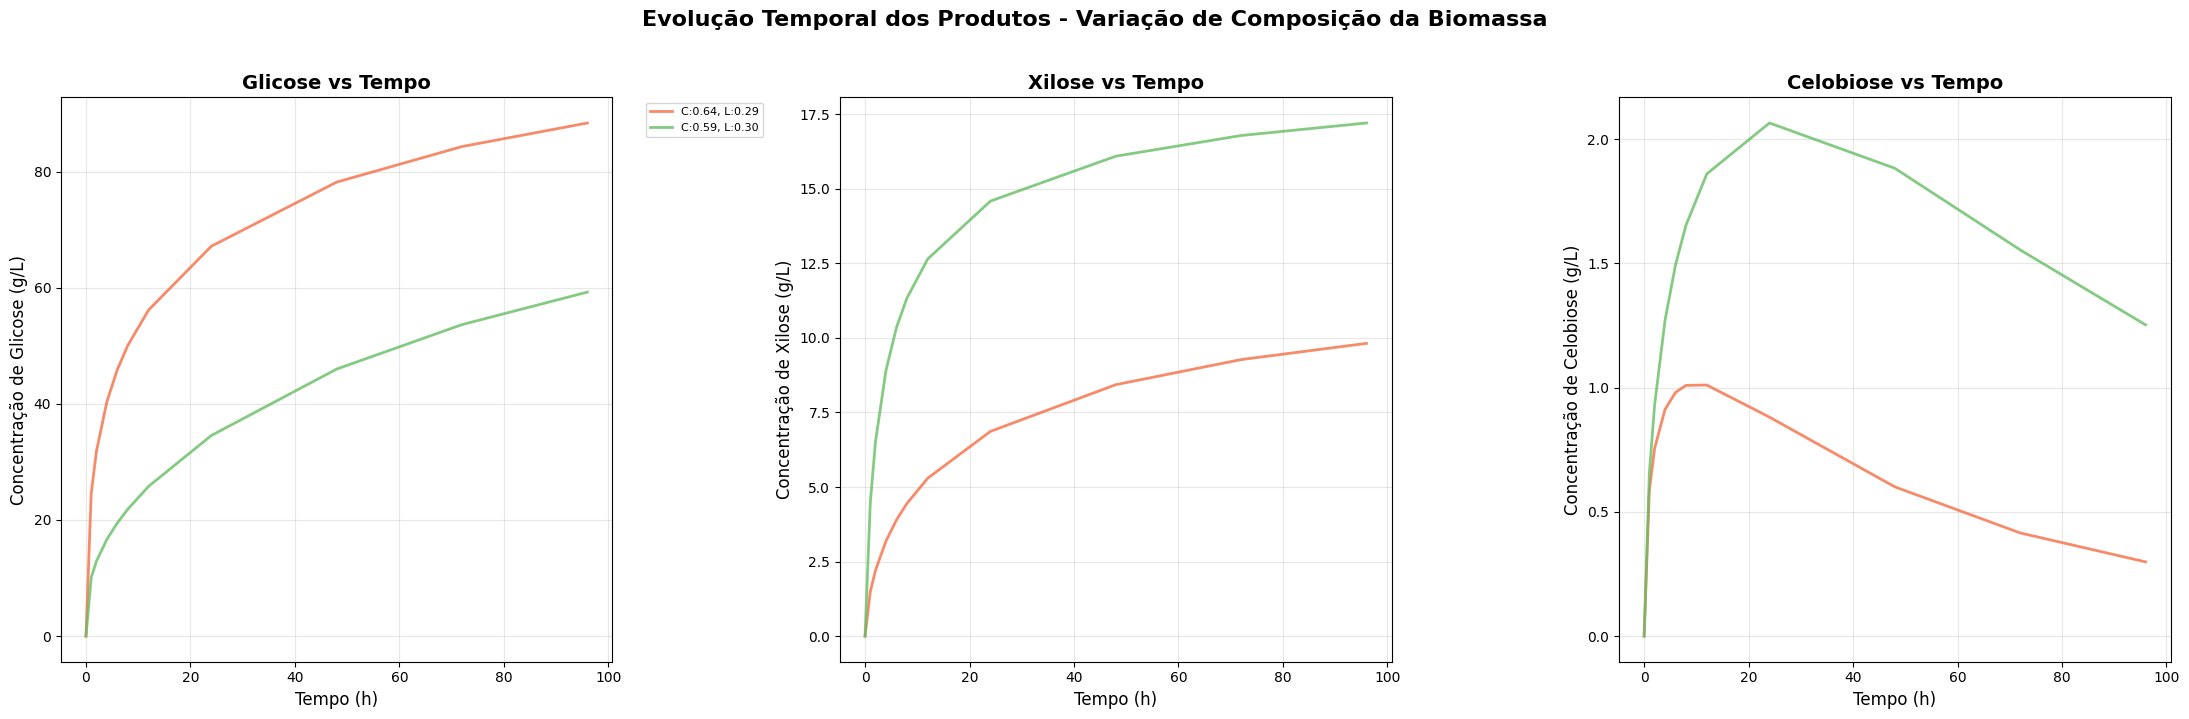

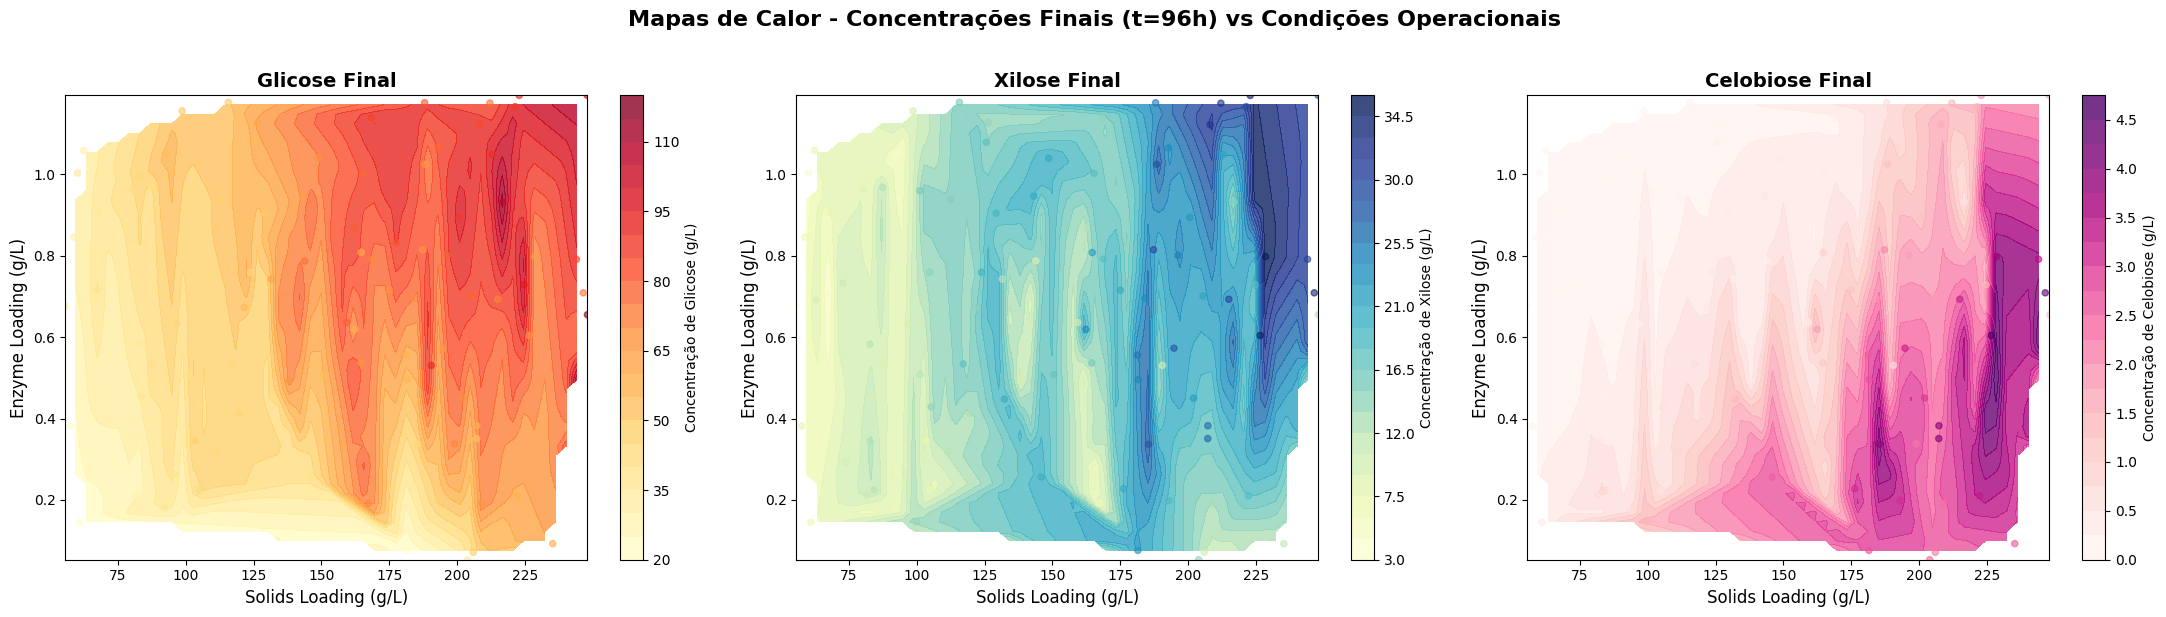


📊 RESUMO DAS CONDIÇÕES PLOTADAS:

🔬 VARIAÇÃO DE ENZYME LOADING:
   • 15 condições plotadas
   • Enzyme Loading: 0.192 - 1.139 g/L
   • Solids Loading: ~154 g/L (fixo)

⚗️  VARIAÇÃO DE SOLIDS LOADING:
   • 15 condições plotadas
   • Solids Loading: 56 - 248 g/L
   • Enzyme Loading: ~0.60 g/L (fixo)

🌱 VARIAÇÃO DE COMPOSIÇÃO:
   • 2 condições plotadas
   • Celulose: 0.590 - 0.639
   • Hemicelulose: 0.071 - 0.114
   • Lignina: 0.290 - 0.295

🎯 TOTAL DE CONDIÇÕES VISUALIZADAS:
   • 32 condições das 100 geradas (32%)
   • Cobertura representativa do espaço de parâmetros

✅ Gráficos de evolução temporal detalhados concluídos!
✅ Os dados mostram a diversidade e qualidade das 100 condições LHS geradas!


In [13]:
# ============================================================================
# 10. EVOLUÇÃO TEMPORAL DETALHADA - MÚLTIPLAS CONDIÇÕES
# ============================================================================

print("\n9. CRIANDO GRÁFICOS DE EVOLUÇÃO TEMPORAL PARA MÚLTIPLAS CONDIÇÕES...")

# Configurar estilo dos gráficos
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Selecionar condições estratégicas para visualização
unique_conditions = synthetic_data_final.drop_duplicates(
    subset=['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]']
)

# ============================================================================
# GRÁFICO 1: EVOLUÇÃO TEMPORAL - DIFERENTES ENZYME LOADINGS
# ============================================================================

fig1, axes1 = plt.subplots(1, 3, figsize=(22, 7))
fig1.suptitle('Evolução Temporal dos Produtos - Variação de Enzyme Loading', 
              fontsize=16, fontweight='bold', y=1.02)

# Selecionar condições com diferentes enzyme loadings (mantendo solids loading similar)
# Calcular diferença absoluta e selecionar as 15 mais próximas de 150 g/L
unique_conditions['solids_diff'] = abs(unique_conditions['Solids Loading [g/L]'] - 150)
enzyme_conditions = unique_conditions.nsmallest(15, 'solids_diff')
enzyme_conditions = enzyme_conditions.sort_values('Enzyme Loading [g/L]')
enzyme_conditions = enzyme_conditions.drop('solids_diff', axis=1)

# Criar colormap para enzyme loading
colors = plt.cm.viridis(np.linspace(0, 1, len(enzyme_conditions)))

# 1.1 Evolução da Glicose
for i, (idx, condition) in enumerate(enzyme_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes1[0].plot(condition_data['Time [h]'], condition_data['Glucose Concentration [g/L]'], 
                 color=colors[i], linewidth=2, alpha=0.8,
                 label=f'E: {condition["Enzyme Loading [g/L]"]:.2f} g/L')

axes1[0].set_xlabel('Tempo (h)', fontsize=12)
axes1[0].set_ylabel('Concentração de Glicose (g/L)', fontsize=12)
axes1[0].set_title('Glicose vs Tempo', fontsize=14, fontweight='bold')
axes1[0].grid(True, alpha=0.3)
axes1[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# 1.2 Evolução da Xilose
for i, (idx, condition) in enumerate(enzyme_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes1[1].plot(condition_data['Time [h]'], condition_data['Xylose Concentration [g/L]'], 
                 color=colors[i], linewidth=2, alpha=0.8,
                 label=f'E: {condition["Enzyme Loading [g/L]"]:.2f} g/L')

axes1[1].set_xlabel('Tempo (h)', fontsize=12)
axes1[1].set_ylabel('Concentração de Xilose (g/L)', fontsize=12)
axes1[1].set_title('Xilose vs Tempo', fontsize=14, fontweight='bold')
axes1[1].grid(True, alpha=0.3)

# 1.3 Evolução da Celobiose
for i, (idx, condition) in enumerate(enzyme_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes1[2].plot(condition_data['Time [h]'], condition_data['Cellobiose Concentration [g/L]'], 
                 color=colors[i], linewidth=2, alpha=0.8,
                 label=f'E: {condition["Enzyme Loading [g/L]"]:.2f} g/L')

axes1[2].set_xlabel('Tempo (h)', fontsize=12)
axes1[2].set_ylabel('Concentração de Celobiose (g/L)', fontsize=12)
axes1[2].set_title('Celobiose vs Tempo', fontsize=14, fontweight='bold')
axes1[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# GRÁFICO 2: EVOLUÇÃO TEMPORAL - DIFERENTES SOLIDS LOADINGS
# ============================================================================

fig2, axes2 = plt.subplots(1, 3, figsize=(22, 7))
fig2.suptitle('Evolução Temporal dos Produtos - Variação de Solids Loading', 
              fontsize=16, fontweight='bold', y=1.02)

# Selecionar condições com diferentes solids loadings (mantendo enzyme loading similar)
# Calcular diferença absoluta e selecionar as 15 mais próximas de 0.6 g/L
unique_conditions['enzyme_diff'] = abs(unique_conditions['Enzyme Loading [g/L]'] - 0.6)
solids_conditions = unique_conditions.nsmallest(15, 'enzyme_diff')
solids_conditions = solids_conditions.sort_values('Solids Loading [g/L]')
solids_conditions = solids_conditions.drop('enzyme_diff', axis=1)

# Criar colormap para solids loading
colors2 = plt.cm.plasma(np.linspace(0, 1, len(solids_conditions)))

# 2.1 Evolução da Glicose
for i, (idx, condition) in enumerate(solids_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes2[0].plot(condition_data['Time [h]'], condition_data['Glucose Concentration [g/L]'], 
                 color=colors2[i], linewidth=2, alpha=0.8,
                 label=f'S: {condition["Solids Loading [g/L]"]:.0f} g/L')

axes2[0].set_xlabel('Tempo (h)', fontsize=12)
axes2[0].set_ylabel('Concentração de Glicose (g/L)', fontsize=12)
axes2[0].set_title('Glicose vs Tempo', fontsize=14, fontweight='bold')
axes2[0].grid(True, alpha=0.3)
axes2[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# 2.2 Evolução da Xilose
for i, (idx, condition) in enumerate(solids_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes2[1].plot(condition_data['Time [h]'], condition_data['Xylose Concentration [g/L]'], 
                 color=colors2[i], linewidth=2, alpha=0.8,
                 label=f'S: {condition["Solids Loading [g/L]"]:.0f} g/L')

axes2[1].set_xlabel('Tempo (h)', fontsize=12)
axes2[1].set_ylabel('Concentração de Xilose (g/L)', fontsize=12)
axes2[1].set_title('Xilose vs Tempo', fontsize=14, fontweight='bold')
axes2[1].grid(True, alpha=0.3)

# 2.3 Evolução da Celobiose
for i, (idx, condition) in enumerate(solids_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes2[2].plot(condition_data['Time [h]'], condition_data['Cellobiose Concentration [g/L]'], 
                 color=colors2[i], linewidth=2, alpha=0.8,
                 label=f'S: {condition["Solids Loading [g/L]"]:.0f} g/L')

axes2[2].set_xlabel('Tempo (h)', fontsize=12)
axes2[2].set_ylabel('Concentração de Celobiose (g/L)', fontsize=12)
axes2[2].set_title('Celobiose vs Tempo', fontsize=14, fontweight='bold')
axes2[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# GRÁFICO 3: EVOLUÇÃO TEMPORAL - DIFERENTES COMPOSIÇÕES DE BIOMASSA
# ============================================================================

fig3, axes3 = plt.subplots(1, 3, figsize=(22, 7))
fig3.suptitle('Evolução Temporal dos Produtos - Variação de Composição da Biomassa', 
              fontsize=16, fontweight='bold', y=1.02)

# Selecionar condições com diferentes composições (fixando condições operacionais)
composition_conditions = unique_conditions[
    (unique_conditions['Solids Loading [g/L]'] > 140) & 
    (unique_conditions['Solids Loading [g/L]'] < 160) &
    (unique_conditions['Enzyme Loading [g/L]'] > 0.5) & 
    (unique_conditions['Enzyme Loading [g/L]'] < 0.7)
].head(12)

# Criar colormap baseado na fração de celulose
cellulose_values = composition_conditions['Cellulose'].values
colors3 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(composition_conditions)))

# 3.1 Evolução da Glicose
for i, (idx, condition) in enumerate(composition_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes3[0].plot(condition_data['Time [h]'], condition_data['Glucose Concentration [g/L]'], 
                 color=colors3[i], linewidth=2, alpha=0.8,
                 label=f'C:{condition["Cellulose"]:.2f}, L:{condition["Lignin"]:.2f}')

axes3[0].set_xlabel('Tempo (h)', fontsize=12)
axes3[0].set_ylabel('Concentração de Glicose (g/L)', fontsize=12)
axes3[0].set_title('Glicose vs Tempo', fontsize=14, fontweight='bold')
axes3[0].grid(True, alpha=0.3)
axes3[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# 3.2 Evolução da Xilose
for i, (idx, condition) in enumerate(composition_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes3[1].plot(condition_data['Time [h]'], condition_data['Xylose Concentration [g/L]'], 
                 color=colors3[i], linewidth=2, alpha=0.8,
                 label=f'H:{condition["Hemicellulose"]:.2f}')

axes3[1].set_xlabel('Tempo (h)', fontsize=12)
axes3[1].set_ylabel('Concentração de Xilose (g/L)', fontsize=12)
axes3[1].set_title('Xilose vs Tempo', fontsize=14, fontweight='bold')
axes3[1].grid(True, alpha=0.3)

# 3.3 Evolução da Celobiose
for i, (idx, condition) in enumerate(composition_conditions.iterrows()):
    condition_data = synthetic_data_final[
        (synthetic_data_final['Cellulose'] == condition['Cellulose']) &
        (synthetic_data_final['Hemicellulose'] == condition['Hemicellulose']) &
        (synthetic_data_final['Lignin'] == condition['Lignin']) &
        (synthetic_data_final['Solids Loading [g/L]'] == condition['Solids Loading [g/L]']) &
        (synthetic_data_final['Enzyme Loading [g/L]'] == condition['Enzyme Loading [g/L]'])
    ].sort_values('Time [h]')
    
    axes3[2].plot(condition_data['Time [h]'], condition_data['Cellobiose Concentration [g/L]'], 
                 color=colors3[i], linewidth=2, alpha=0.8,
                 label=f'C:{condition["Cellulose"]:.2f}')

axes3[2].set_xlabel('Tempo (h)', fontsize=12)
axes3[2].set_ylabel('Concentração de Celobiose (g/L)', fontsize=12)
axes3[2].set_title('Celobiose vs Tempo', fontsize=14, fontweight='bold')
axes3[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# GRÁFICO 4: MAPA DE CALOR DAS CONCENTRAÇÕES FINAIS
# ============================================================================

fig4, axes4 = plt.subplots(1, 3, figsize=(22, 6))
fig4.suptitle('Mapas de Calor - Concentrações Finais (t=96h) vs Condições Operacionais', 
              fontsize=16, fontweight='bold', y=1.02)

# Dados finais
final_data = synthetic_data_final[synthetic_data_final['Time [h]'] == 96]

# Criar grids para interpolação
from scipy.interpolate import griddata

# Definir grids regulares
solids_grid = np.linspace(final_data['Solids Loading [g/L]'].min(), 
                          final_data['Solids Loading [g/L]'].max(), 50)
enzyme_grid = np.linspace(final_data['Enzyme Loading [g/L]'].min(), 
                          final_data['Enzyme Loading [g/L]'].max(), 50)
S_grid, E_grid = np.meshgrid(solids_grid, enzyme_grid)

# 4.1 Mapa de calor - Glicose
glucose_grid = griddata(
    (final_data['Solids Loading [g/L]'], final_data['Enzyme Loading [g/L]']),
    final_data['Glucose Concentration [g/L]'],
    (S_grid, E_grid),
    method='linear'
)

im1 = axes4[0].contourf(S_grid, E_grid, glucose_grid, levels=20, cmap='YlOrRd', alpha=0.8)
axes4[0].scatter(final_data['Solids Loading [g/L]'], final_data['Enzyme Loading [g/L]'], 
                c=final_data['Glucose Concentration [g/L]'], cmap='YlOrRd', s=20, alpha=0.6)
cbar1 = plt.colorbar(im1, ax=axes4[0])
cbar1.set_label('Concentração de Glicose (g/L)', fontsize=10)
axes4[0].set_xlabel('Solids Loading (g/L)', fontsize=12)
axes4[0].set_ylabel('Enzyme Loading (g/L)', fontsize=12)
axes4[0].set_title('Glicose Final', fontsize=14, fontweight='bold')

# 4.2 Mapa de calor - Xilose
xylose_grid = griddata(
    (final_data['Solids Loading [g/L]'], final_data['Enzyme Loading [g/L]']),
    final_data['Xylose Concentration [g/L]'],
    (S_grid, E_grid),
    method='linear'
)

im2 = axes4[1].contourf(S_grid, E_grid, xylose_grid, levels=20, cmap='YlGnBu', alpha=0.8)
axes4[1].scatter(final_data['Solids Loading [g/L]'], final_data['Enzyme Loading [g/L]'], 
                c=final_data['Xylose Concentration [g/L]'], cmap='YlGnBu', s=20, alpha=0.6)
cbar2 = plt.colorbar(im2, ax=axes4[1])
cbar2.set_label('Concentração de Xilose (g/L)', fontsize=10)
axes4[1].set_xlabel('Solids Loading (g/L)', fontsize=12)
axes4[1].set_ylabel('Enzyme Loading (g/L)', fontsize=12)
axes4[1].set_title('Xilose Final', fontsize=14, fontweight='bold')

# 4.3 Mapa de calor - Celobiose
cellobiose_grid = griddata(
    (final_data['Solids Loading [g/L]'], final_data['Enzyme Loading [g/L]']),
    final_data['Cellobiose Concentration [g/L]'],
    (S_grid, E_grid),
    method='linear'
)

im3 = axes4[2].contourf(S_grid, E_grid, cellobiose_grid, levels=20, cmap='RdPu', alpha=0.8)
axes4[2].scatter(final_data['Solids Loading [g/L]'], final_data['Enzyme Loading [g/L]'], 
                c=final_data['Cellobiose Concentration [g/L]'], cmap='RdPu', s=20, alpha=0.6)
cbar3 = plt.colorbar(im3, ax=axes4[2])
cbar3.set_label('Concentração de Celobiose (g/L)', fontsize=10)
axes4[2].set_xlabel('Solids Loading (g/L)', fontsize=12)
axes4[2].set_ylabel('Enzyme Loading (g/L)', fontsize=12)
axes4[2].set_title('Celobiose Final', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# ESTATÍSTICAS DAS CONDIÇÕES PLOTADAS
# ============================================================================

print(f"\n📊 RESUMO DAS CONDIÇÕES PLOTADAS:")
print("=" * 50)

print(f"\n🔬 VARIAÇÃO DE ENZYME LOADING:")
print(f"   • {len(enzyme_conditions)} condições plotadas")
print(f"   • Enzyme Loading: {enzyme_conditions['Enzyme Loading [g/L]'].min():.3f} - {enzyme_conditions['Enzyme Loading [g/L]'].max():.3f} g/L")
print(f"   • Solids Loading: ~{enzyme_conditions['Solids Loading [g/L]'].mean():.0f} g/L (fixo)")

print(f"\n⚗️  VARIAÇÃO DE SOLIDS LOADING:")
print(f"   • {len(solids_conditions)} condições plotadas")
print(f"   • Solids Loading: {solids_conditions['Solids Loading [g/L]'].min():.0f} - {solids_conditions['Solids Loading [g/L]'].max():.0f} g/L")
print(f"   • Enzyme Loading: ~{solids_conditions['Enzyme Loading [g/L]'].mean():.2f} g/L (fixo)")

print(f"\n🌱 VARIAÇÃO DE COMPOSIÇÃO:")
print(f"   • {len(composition_conditions)} condições plotadas")
print(f"   • Celulose: {composition_conditions['Cellulose'].min():.3f} - {composition_conditions['Cellulose'].max():.3f}")
print(f"   • Hemicelulose: {composition_conditions['Hemicellulose'].min():.3f} - {composition_conditions['Hemicellulose'].max():.3f}")
print(f"   • Lignina: {composition_conditions['Lignin'].min():.3f} - {composition_conditions['Lignin'].max():.3f}")

print(f"\n🎯 TOTAL DE CONDIÇÕES VISUALIZADAS:")
total_conditions = len(enzyme_conditions) + len(solids_conditions) + len(composition_conditions)
print(f"   • {total_conditions} condições das 100 geradas ({total_conditions/100*100:.0f}%)")
print(f"   • Cobertura representativa do espaço de parâmetros")

print("\n✅ Gráficos de evolução temporal detalhados concluídos!")
print("✅ Os dados mostram a diversidade e qualidade das 100 condições LHS geradas!")